# 01 Rebuild road graph and movement segments

This notebook starts from `dataset/*.csv` and `baoding/Road.shp`, rebuilds the GraphML into `outputs_pipeline_aligned/00_graph`, calculates network routes, expands route-level records into segment-level rows, and writes the filtered segment table used downstream.

Run this after `00_pipeline_setup_and_manifest.ipynb`.


In [1]:
# =========================================================
# 0. Configuration and imports
#    Clean aligned rebuild version
# =========================================================
from pathlib import Path
from collections import defaultdict
from typing import Any, Dict, List, Optional
import ast
import hashlib
import json
import math
import os
import re

import numpy as np
import pandas as pd
from tqdm import tqdm

# Spatial and graph dependencies are imported inside functions where possible.

# ---------- project manifest ----------
PROJECT_ROOT = Path.cwd()
PIPELINE_ROOT = PROJECT_ROOT / "outputs_pipeline_aligned"
MANIFEST_PATH = PIPELINE_ROOT / "pipeline_manifest.json"

if MANIFEST_PATH.exists():
    PIPELINE_MANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
else:
    PIPELINE_MANIFEST = {}

DATA_DIR = Path(PIPELINE_MANIFEST.get("data_dir", PROJECT_ROOT / "dataset"))
BAODING_DIR = Path(PIPELINE_MANIFEST.get("baoding_dir", PROJECT_ROOT / "baoding"))
GRAPH_DIR = Path(PIPELINE_MANIFEST.get("graph_file", PIPELINE_ROOT / "00_graph" / "baoding_aligned.graphml")).parent
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# ---------- input paths ----------
WAYBILL_CSV = DATA_DIR / "all_waybill_info.csv"
WAVE_CSV = DATA_DIR / "courier_wave_info.csv"
DISPATCH_RIDER_CSV = DATA_DIR / "dispatch_rider.csv"
DISPATCH_WAYBILL_CSV = DATA_DIR / "dispatch_waybill.csv"

# Road network is rebuilt into the pipeline folder so every downstream notebook uses the same file.
ROAD_SHP = Path(PIPELINE_MANIFEST.get("road_shp", BAODING_DIR / "保定数据" / "Road.shp"))
GRAPH_FILE = Path(PIPELINE_MANIFEST.get("graph_file", GRAPH_DIR / "baoding_aligned.graphml"))
GRAPH_FILE.parent.mkdir(parents=True, exist_ok=True)

# ---------- outputs ----------
OUTPUT_DIR = Path(PIPELINE_MANIFEST.get("raw_segment_dir", PIPELINE_ROOT / "01_raw_segments"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MOVEMENTS_ROUTES_CSV = OUTPUT_DIR / "courier_movements_midpoint_routes.csv"
ROUTE_DISTANCE_CSV = OUTPUT_DIR / "courier_final_distances_midpoint_routes_virtual_edge.csv"
SEGMENT_DISTANCE_CSV = OUTPUT_DIR / "courier_final_distances_segments_virtual_edge.csv"
FILTERED_CSV = OUTPUT_DIR / "courier_final_distances_filtered.csv"
FILTER_STAGE_SUMMARY_CSV = OUTPUT_DIR / "filter_stage_summary.csv"
RAW_STAGE_MANIFEST_JSON = OUTPUT_DIR / "raw_stage_manifest.json"

# ---------- resume / checkpoint behavior ----------
# Full aligned rebuild defaults. Change these only after the first successful full run.
RESUME_FROM_EXISTING = False
FORCE_REBUILD_MOVEMENTS = True
FORCE_RECALCULATE_ROUTE_DISTANCES = True
FORCE_EXPAND_SEGMENTS = True
FORCE_REFILTER_SEGMENTS = True
CHECK_REQUIRED_COLUMNS_ON_RESUME = True

# ---------- coordinate transform ----------
COORD_DIVISOR = 1_000_000
LNG_SHIFT = 59.0822
LAT_SHIFT = 7.0005

# ---------- study area ----------
LAT_MIN = 38.80
LAT_MAX = 38.95
LNG_MIN = 115.37
LNG_MAX = 115.61
BBOX_WGS84 = (LNG_MIN, LAT_MIN, LNG_MAX, LAT_MAX)

# ---------- road graph build ----------
# Keep this True for a fully reproducible rebuild from baoding/Road.shp.
RUN_BUILD_ROAD_GRAPH = True
ROAD_REPAIR_OUTPUT_DIR = GRAPH_DIR / "road_repair_outputs"

# ---------- filter thresholds ----------
FILTER_STAGE_0_ENABLE = True
FILTER_DURATION_MIN = 300
FILTER_DURATION_MAX = 3600
FILTER_FINAL_DIST_MIN = 300
FILTER_SPEED_MIN_KMH = 3.6
FILTER_SPEED_MAX_KMH = 60
FILTER_ENABLE_OFFSET_RATIO = True
FILTER_OFFSET_RATIO_MAX = 0.10
FILTER_ENABLE_ROUTE_RATIO = True
FILTER_ROUTE_RATIO_COL = "final_to_straight_ratio"
FILTER_ROUTE_RATIO_MAX = 2.5
FILTER_DROP_PAIRS = ["GRAB -> GRAB"]
FILTER_STAGE_5_ENABLE = True

RATIO_EPS = 1e-6

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# ---------- stage output helpers ----------
def file_fingerprint(path):
    path = Path(path)
    if not path.exists():
        return None
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(1024 * 1024)
            if not b:
                break
            h.update(b)
    return {
        "path": str(path),
        "size_bytes": int(path.stat().st_size),
        "mtime": float(path.stat().st_mtime),
        "md5": h.hexdigest(),
    }


def csv_has_required_columns(path, required_columns):
    path = Path(path)
    if not required_columns:
        return True
    if not path.exists():
        return False
    try:
        cols = list(pd.read_csv(path, nrows=0).columns)
    except Exception as exc:
        print("cannot inspect existing csv, will rebuild:", path, exc)
        return False
    missing = [c for c in required_columns if c not in cols]
    if missing:
        print("existing csv is missing required columns, will rebuild:", path)
        print("missing columns:", missing[:20])
        return False
    return True


def should_reuse_csv(path, force=False, required_columns=None):
    path = Path(path)
    if force or not RESUME_FROM_EXISTING or not path.exists():
        return False
    if CHECK_REQUIRED_COLUMNS_ON_RESUME and required_columns:
        return csv_has_required_columns(path, required_columns)
    return True


def read_existing_csv(path, required_columns=None):
    path = Path(path)
    print("reuse existing csv:", path)
    return pd.read_csv(path)


def write_csv_atomic(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_name(path.name + ".tmp")
    df.to_csv(tmp_path, index=index)
    os.replace(str(tmp_path), str(path))
    print("saved:", path)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PIPELINE_ROOT:", PIPELINE_ROOT)
print("ROAD_SHP:", ROAD_SHP)
print("GRAPH_FILE:", GRAPH_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /Users/kwk1001/Desktop/Meituan
PIPELINE_ROOT: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned
ROAD_SHP: /Users/kwk1001/Desktop/Meituan/baoding/保定数据/Road.shp
GRAPH_FILE: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.graphml
OUTPUT_DIR: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments


## 1. Helper functions for raw data and route construction

In [2]:
# =========================================================
# 1. Raw data helpers
# =========================================================
def read_csv_checked(path: Path, **kwargs) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")
    return pd.read_csv(path, **kwargs)


def drop_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in df.columns if not str(c).startswith("Unnamed:")]
    return df[cols].copy()


def coordinate_transform(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """Convert shifted integer coordinates into shifted WGS84-like lon/lat."""
    out = df.copy()
    lng_col = f"{prefix}_lng"
    lat_col = f"{prefix}_lat"
    missing = [c for c in [lng_col, lat_col] if c not in out.columns]
    if missing:
        raise ValueError(f"Missing coordinate columns for {prefix}: {missing}")
    out[lng_col] = pd.to_numeric(out[lng_col], errors="coerce") / COORD_DIVISOR - LNG_SHIFT
    out[lat_col] = pd.to_numeric(out[lat_col], errors="coerce") / COORD_DIVISOR - LAT_SHIFT
    return out


def parse_order_ids(x):
    if pd.isna(x):
        return []
    if isinstance(x, (list, tuple, set)):
        return [int(v) for v in x if pd.notna(v)]

    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple, set)):
            return [int(z) for z in v if pd.notna(z)]
    except Exception:
        pass

    s = s.strip("()[]{}")
    out = []
    for part in s.split(","):
        part = part.strip()
        if not part:
            continue
        try:
            out.append(int(part))
        except Exception:
            continue
    return out


def clean_waybill_table(waybill: pd.DataFrame) -> pd.DataFrame:
    """Clean waybill table and remove rejected waybills.

    The previous notebook created a filtered table but later merged with the unfiltered table.
    This function applies the filter to the table that is actually used downstream.
    """
    df = drop_unnamed_columns(waybill)

    for prefix in ["sender", "recipient", "grab"]:
        df = coordinate_transform(df, prefix)

    # Fix the rejected-waybill filter. The real column in the provided csv is is_courier_grabbed.
    grab_col = None
    for candidate in ["is_courier_grabbed", "is_courier_grab"]:
        if candidate in df.columns:
            grab_col = candidate
            break
    if grab_col is not None:
        df = df[pd.to_numeric(df[grab_col], errors="coerce").fillna(0).astype(int) == 1].copy()

    if "grab_time" in df.columns:
        df = df[pd.to_numeric(df["grab_time"], errors="coerce").fillna(0).astype(int) > 0].copy()

    for col in ["order_id", "courier_id"]:
        df[col] = pd.to_numeric(df[col], errors="raise").astype("int64")

    # Keep the latest accepted waybill for the same courier-order pair.
    # This preserves the original intent while making duplicates deterministic.
    if "grab_time" in df.columns:
        df["grab_time"] = pd.to_numeric(df["grab_time"], errors="coerce").fillna(0).astype("int64")
        df = df.sort_values(["courier_id", "order_id", "grab_time"], kind="stable")
        df = df.drop_duplicates(["courier_id", "order_id"], keep="last").copy()

    return df.reset_index(drop=True)


def clean_wave_table(wave: pd.DataFrame) -> pd.DataFrame:
    df = drop_unnamed_columns(wave)
    df["order_ids"] = df["order_ids"].apply(parse_order_ids)

    out = (
        df.explode("order_ids")
          .rename(columns={"order_ids": "order_id", "dt": "wave_dt"})
          .dropna(subset=["order_id"])
          .copy()
    )
    for col in ["wave_dt", "courier_id", "wave_id", "order_id"]:
        out[col] = pd.to_numeric(out[col], errors="raise").astype("int64")
    return out.reset_index(drop=True)


def build_events(df_merged: pd.DataFrame) -> pd.DataFrame:
    """Vectorized event construction from merged wave-waybill rows."""
    common = ["wave_dt", "courier_id", "wave_id", "order_id", "estimate_arrived_time"]
    event_specs = [
        ("GRAB", "grab_time", "grab_lng", "grab_lat", "Spot_Where_Grabbed"),
        ("FETCH", "fetch_time", "sender_lng", "sender_lat", "Merchant"),
        ("DELIVER", "arrive_time", "recipient_lng", "recipient_lat", "Customer"),
    ]

    pieces = []
    for action, time_col, lng_col, lat_col, location_type in event_specs:
        need_cols = common + [time_col, lng_col, lat_col]
        missing = [c for c in need_cols if c not in df_merged.columns]
        if missing:
            raise ValueError(f"Missing columns for {action}: {missing}")

        tmp = df_merged[need_cols].copy()
        tmp[time_col] = pd.to_numeric(tmp[time_col], errors="coerce")
        tmp = tmp[tmp[time_col].fillna(0) > 0].copy()
        if tmp.empty:
            continue

        tmp = tmp.rename(columns={
            "wave_dt": "dt",
            time_col: "time",
            lng_col: "lng",
            lat_col: "lat",
        })
        tmp["action"] = action
        tmp["location_type"] = location_type
        tmp["time"] = tmp["time"].astype("int64")
        for col in ["dt", "courier_id", "wave_id", "order_id"]:
            tmp[col] = pd.to_numeric(tmp[col], errors="raise").astype("int64")
        pieces.append(tmp[[
            "dt", "courier_id", "wave_id", "order_id", "action", "time",
            "lng", "lat", "location_type", "estimate_arrived_time",
        ]])

    if not pieces:
        return pd.DataFrame(columns=[
            "dt", "courier_id", "wave_id", "order_id", "action", "time",
            "lng", "lat", "location_type", "estimate_arrived_time",
        ])

    df_events = pd.concat(pieces, ignore_index=True)
    action_rank = {"GRAB": 0, "FETCH": 1, "DELIVER": 2}
    df_events["action_rank"] = df_events["action"].map(action_rank).fillna(9).astype(int)
    df_events = (
        df_events.sort_values(["dt", "courier_id", "wave_id", "time", "action_rank"], kind="stable")
                 .reset_index(drop=True)
    )
    return df_events.drop(columns=["action_rank"])

def build_midpoint_routes(df_events: pd.DataFrame) -> pd.DataFrame:
    """Build route-level movements.

    GRAB events inside a route are stored as midpoints. The route end is the next FETCH or DELIVER.
    For later segment expansion, each midpoint also carries time pressure evaluated after the GRAB event.
    """
    if df_events.empty:
        return pd.DataFrame()

    final_rows = []
    max_midpoints = 0

    grouped = df_events.groupby(["dt", "courier_id", "wave_id"], sort=False)

    for (wave_dt, cid, wid), group in tqdm(grouped, total=grouped.ngroups, desc="build midpoint routes"):
        if group.empty:
            continue

        tmp = group[["order_id", "estimate_arrived_time"]].copy()
        tmp = tmp[tmp["estimate_arrived_time"].fillna(0) > 0]
        order_deadline = tmp.groupby("order_id")["estimate_arrived_time"].min().to_dict()

        rows = list(group.itertuples(index=False))
        active_orders = set()

        def apply_event(evt):
            oid = int(evt.order_id)
            if evt.action in ("GRAB", "FETCH"):
                active_orders.add(oid)
            elif evt.action == "DELIVER":
                active_orders.discard(oid)

        def compute_pressure(start_time):
            deadlines = []
            for oid in active_orders:
                d = order_deadline.get(oid, np.nan)
                if pd.notna(d) and int(d) > 0:
                    deadlines.append(int(d))
            if not deadlines:
                return np.nan, np.nan
            min_deadline = min(deadlines)
            return min_deadline, min_deadline - int(start_time)

        current_start = rows[0]
        apply_event(current_start)
        cur_min_deadline, cur_pressure = compute_pressure(current_start.time)

        midpoint_buffer = []

        for i in range(1, len(rows)):
            row = rows[i]

            if row.action == "GRAB":
                apply_event(row)
                mid_min_deadline, mid_pressure = compute_pressure(row.time)
                midpoint_buffer.append({
                    "event": row,
                    "min_deadline_time": mid_min_deadline,
                    "time_pressure_sec": mid_pressure,
                })
                continue

            segment = {
                "dt": int(wave_dt),
                "courier_id": int(cid),
                "wave_id": int(wid),
                "start_time": int(current_start.time),
                "end_time": int(row.time),
                "duration": int(row.time) - int(current_start.time),
                "start_action": current_start.action,
                "end_action": row.action,
                "start_order_id": int(current_start.order_id),
                "end_order_id": int(row.order_id),
                "start_type": current_start.location_type,
                "end_type": row.location_type,
                "start_lng": current_start.lng,
                "start_lat": current_start.lat,
                "end_lng": row.lng,
                "end_lat": row.lat,
                "min_deadline_time": cur_min_deadline,
                "time_pressure_sec": cur_pressure,
            }

            max_midpoints = max(max_midpoints, len(midpoint_buffer))

            for idx, mid_info in enumerate(midpoint_buffer, start=1):
                mid = mid_info["event"]
                segment[f"mid_{idx}_time"] = int(mid.time)
                segment[f"mid_{idx}_lng"] = mid.lng
                segment[f"mid_{idx}_lat"] = mid.lat
                segment[f"mid_{idx}_order_id"] = int(mid.order_id)
                segment[f"mid_{idx}_min_deadline_time"] = mid_info["min_deadline_time"]
                segment[f"mid_{idx}_time_pressure_sec"] = mid_info["time_pressure_sec"]
                segment[f"mid_{idx}_time_pressure_min"] = mid_info["time_pressure_sec"] / 60.0 if pd.notna(mid_info["time_pressure_sec"]) else np.nan

            final_rows.append(segment)

            current_start = row
            midpoint_buffer = []
            apply_event(row)
            cur_min_deadline, cur_pressure = compute_pressure(current_start.time)

    out = pd.DataFrame(final_rows)
    if out.empty:
        return out

    out = out[out["duration"] >= 0].copy()
    out["time_pressure_min"] = out["time_pressure_sec"] / 60.0

    base_cols = [
        "dt", "courier_id", "wave_id",
        "start_time", "end_time", "duration",
        "start_action", "end_action",
        "start_order_id", "end_order_id",
        "start_type", "end_type",
        "start_lng", "start_lat", "end_lng", "end_lat",
        "min_deadline_time", "time_pressure_sec", "time_pressure_min",
    ]
    mid_cols = []
    for k in range(1, max_midpoints + 1):
        mid_cols.extend([
            f"mid_{k}_time", f"mid_{k}_lng", f"mid_{k}_lat", f"mid_{k}_order_id",
            f"mid_{k}_min_deadline_time", f"mid_{k}_time_pressure_sec", f"mid_{k}_time_pressure_min",
        ])

    final_cols = base_cols + mid_cols
    for col in final_cols:
        if col not in out.columns:
            out[col] = np.nan
    return out[final_cols].reset_index(drop=True)


def load_and_build_midpoint_routes() -> pd.DataFrame:
    waybill_raw = read_csv_checked(WAYBILL_CSV)
    wave_raw = read_csv_checked(WAVE_CSV)

    waybill = clean_waybill_table(waybill_raw)
    wave_orders = clean_wave_table(wave_raw)

    merged = pd.merge(
        wave_orders[["wave_dt", "courier_id", "wave_id", "order_id"]],
        waybill,
        on=["order_id", "courier_id"],
        how="inner",
    )

    events = build_events(merged)
    routes = build_midpoint_routes(events)

    print("waybill raw rows:", len(waybill_raw))
    print("waybill accepted rows used:", len(waybill))
    print("wave-order rows:", len(wave_orders))
    print("merged rows:", len(merged))
    print("event rows:", len(events))
    print("midpoint route rows:", len(routes))

    return routes


In [ ]:
# =========================================================
# 2. Build or load midpoint route-level movements
# =========================================================
MOVEMENT_REQUIRED_COLUMNS = [
    "dt", "courier_id", "wave_id",
    "start_time", "end_time", "duration",
    "start_action", "end_action",
    "start_lng", "start_lat", "end_lng", "end_lat",
]

if should_reuse_csv(MOVEMENTS_ROUTES_CSV, force=FORCE_REBUILD_MOVEMENTS, required_columns=MOVEMENT_REQUIRED_COLUMNS):
    routes = read_existing_csv(MOVEMENTS_ROUTES_CSV, required_columns=MOVEMENT_REQUIRED_COLUMNS)
else:
    routes = load_and_build_midpoint_routes()
    write_csv_atomic(routes, MOVEMENTS_ROUTES_CSV, index=False)

print("midpoint route rows:", len(routes))
routes.head()


build midpoint routes:  15%|█▌        | 31609/206748 [00:12<01:05, 2677.45it/s]

## 2. Optional road network construction

Run this only when `baoding_clear.graphml` does not already exist or when the road shapefile has changed.

In [ ]:
# =========================================================
# 3. Optional road graph builder
#    Source-preserving road class transfer
#    Python 3.8 compatible
# =========================================================

from pathlib import Path
from collections import defaultdict
import os
import json
import math

import numpy as np
import pandas as pd


def build_road_graph_from_shp(
    input_shp=ROAD_SHP,
    output_graphml=GRAPH_FILE,
    bbox_wgs84=BBOX_WGS84,
    endpoint_snap_tol_m=5.0,
    coord_round=3,
    add_reverse_edges=True,
    output_dir=ROAD_REPAIR_OUTPUT_DIR,
    road_class_col=None,
    min_split_segment_length_m=0.20,
    resolve_duplicate_geometries=True,
):
    """
    Build a road GraphML from Road.shp while preserving road class attributes.

    This follows the previously validated logic:

    1. Read original Road.shp.
    2. Clean valid line geometries.
    3. Clip to study bbox.
    4. Project to metric CRS if needed.
    5. Preserve source road id and source road class.
    6. Snap close endpoints within endpoint_snap_tol_m.
    7. Split each original source road by geometric intersections.
    8. Every split segment inherits the parent source road attributes.
    9. Resolve coincident duplicate geometries by road class priority.
    10. Build directed GraphML with forward and reverse edges.

    It does not add endpoint-to-line connector repair. This keeps the builder
    aligned with the original validated source-preserving repair.
    """

    import geopandas as gpd
    import networkx as nx
    import osmnx as ox
    from scipy.spatial import cKDTree
    from shapely.geometry import GeometryCollection, LineString, MultiLineString, Point, box
    from shapely.ops import substring

    try:
        from tqdm import tqdm
    except Exception:
        tqdm = None

    input_shp = Path(input_shp)
    output_graphml = Path(output_graphml)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)
    output_graphml.parent.mkdir(parents=True, exist_ok=True)

    repaired_gpkg = output_dir / "Road_source_preserving_segments.gpkg"
    duplicate_csv = output_dir / "Road_duplicate_segment_resolution.csv"
    split_diag_csv = output_dir / "Road_source_preserving_split_diagnostics.csv"
    diag_json = output_dir / "road_source_preserving_diagnostics.json"

    ROAD_CLASS_CANDIDATES = [
        "EN_Class",
        "CN_Class",
        "highway",
        "road_class_en",
        "road_class_cn",
        "fclass",
        "type",
        "class",
        "Kind",
        "kind",
    ]

    ROAD_CLASS_PRIORITY = {
        "nationalRoad": 100,
        "provincialRoad": 90,
        "secondaryRoad": 80,
        "levelThreeRoad": 70,
        "levelFourRoad": 60,
        "overPass": 50,
        "underPass": 50,
        "Unknown": 0,
        "Unknown / missing": 0,
    }

    # -----------------------------------------------------
    # Compatibility helpers
    # -----------------------------------------------------

    def project_gdf_to_utm_compat(gdf):
        """
        Project a GeoDataFrame to metric CRS with OSMnx and GeoPandas compatibility.
        """

        if gdf.crs is None:
            raise ValueError("Cannot project GeoDataFrame with missing CRS.")

        if not gdf.crs.is_geographic:
            return gdf

        try:
            return ox.project_gdf(gdf)
        except Exception:
            pass

        try:
            return ox.projection.project_gdf(gdf)
        except Exception as exc:
            print("OSMnx project_gdf unavailable or failed:", repr(exc))

        try:
            utm_crs = gdf.estimate_utm_crs()
            print("Projecting with GeoPandas estimated UTM CRS:", utm_crs)
            return gdf.to_crs(utm_crs)
        except Exception as exc:
            print("GeoPandas estimate_utm_crs unavailable or failed:", repr(exc))

        gdf_wgs = gdf.to_crs(epsg=4326)
        minx, miny, maxx, maxy = gdf_wgs.total_bounds
        lon = float((minx + maxx) / 2.0)
        lat = float((miny + maxy) / 2.0)

        zone = int(math.floor((lon + 180.0) / 6.0) + 1)
        epsg = 32600 + zone if lat >= 0 else 32700 + zone

        print("Projecting with manual UTM fallback EPSG:%d" % epsg)
        return gdf.to_crs(epsg=epsg)

    def graph_from_gdfs_compat(nodes_gdf, edges_gdf, graph_attrs):
        try:
            return ox.graph_from_gdfs(nodes_gdf, edges_gdf, graph_attrs=graph_attrs)
        except AttributeError:
            return ox.convert.graph_from_gdfs(nodes_gdf, edges_gdf, graph_attrs=graph_attrs)

    def save_graphml_compat(G, filepath):
        try:
            ox.save_graphml(G, filepath=str(filepath))
        except AttributeError:
            ox.io.save_graphml(G, filepath=str(filepath))

    # -----------------------------------------------------
    # Text and type helpers
    # -----------------------------------------------------

    def clean_text(v):
        if pd.isna(v):
            return ""
        s = str(v).strip()
        if s in {"", "nan", "None", "<NA>", "[]"}:
            return ""
        return s

    def normalize_road_class(v):
        s = clean_text(v)
        if s == "":
            return "Unknown"

        s = s.replace("[", "").replace("]", "")
        s = s.replace("'", "").replace('"', "")
        s = s.strip()

        if ";" in s:
            s = s.split(";")[0].strip()
        elif "," in s:
            s = s.split(",")[0].strip()

        if s == "":
            return "Unknown"

        return s

    def class_priority(cls):
        cls = normalize_road_class(cls)
        return ROAD_CLASS_PRIORITY.get(cls, 10)

    def to_python_scalar(v):
        try:
            if pd.isna(v):
                return None
        except Exception:
            pass

        if hasattr(v, "item"):
            try:
                return v.item()
            except Exception:
                pass

        if isinstance(v, (str, int, float, bool)):
            return v

        return str(v)

    def to_int_or_none(v):
        if v is None:
            return None

        try:
            if pd.isna(v):
                return None
        except Exception:
            pass

        try:
            return int(v)
        except Exception:
            try:
                return int(float(v))
            except Exception:
                return None

    def infer_crs_if_missing(gdf):
        if gdf.crs is not None:
            return gdf

        minx, miny, maxx, maxy = gdf.total_bounds
        looks_lonlat = (
            -180 <= minx <= 180
            and -180 <= maxx <= 180
            and -90 <= miny <= 90
            and -90 <= maxy <= 90
        )

        if looks_lonlat:
            print("CRS missing; coordinates look like lon/lat, setting EPSG:4326")
            return gdf.set_crs(epsg=4326)

        raise ValueError("Road file has no CRS and cannot be safely inferred.")

    # -----------------------------------------------------
    # Geometry helpers
    # -----------------------------------------------------

    def keep_valid_lines(gdf):
        gdf = gdf[gdf.geometry.notna()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        gdf = gdf[gdf.geom_type.isin(["LineString", "MultiLineString"])].copy()
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
        gdf = gdf[gdf.geometry.notna()].copy()
        gdf = gdf[gdf.geom_type == "LineString"].copy()

        keep = []
        for geom in gdf.geometry:
            try:
                keep.append(len(list(geom.coords)) >= 2 and geom.length > 0)
            except Exception:
                keep.append(False)

        return gdf[np.array(keep, dtype=bool)].reset_index(drop=True)

    def clip_by_bbox_wgs84(gdf, bbox_wgs84):
        if bbox_wgs84 is None:
            return gdf

        west, south, east, north = bbox_wgs84

        bbox_gdf = gpd.GeoDataFrame(
            {"geometry": [box(west, south, east, north)]},
            crs="EPSG:4326",
        )

        if gdf.crs != bbox_gdf.crs:
            bbox_gdf = bbox_gdf.to_crs(gdf.crs)

        bbox_geom = bbox_gdf.geometry.iloc[0]
        out = gdf[gdf.geometry.intersects(bbox_geom)].copy()

        if len(out) == 0:
            return out

        out = gpd.clip(out, bbox_gdf)
        return keep_valid_lines(out)

    def choose_road_class_column(gdf, explicit_col):
        if explicit_col is not None:
            if explicit_col not in gdf.columns:
                raise ValueError("road_class_col not found: %s" % explicit_col)
            print("Using explicit road class column:", explicit_col)
            return explicit_col

        best_col = None
        best_share = 0.0
        best_unique = 0

        print("\nRoad class column candidates:")
        for c in ROAD_CLASS_CANDIDATES:
            if c not in gdf.columns:
                continue

            vals = gdf[c].apply(clean_text)
            nonempty_share = float((vals != "").mean())
            unique_n = int(vals[vals != ""].nunique())

            print("  %s: non-empty share %.3f, unique %d" % (c, nonempty_share, unique_n))

            if nonempty_share > best_share:
                best_col = c
                best_share = nonempty_share
                best_unique = unique_n

        if best_col is None or best_share <= 0:
            print("No usable road class column found. All roads will be Unknown.")
            return None

        print(
            "Selected road class column: %s, non-empty share %.3f, unique %d"
            % (best_col, best_share, best_unique)
        )
        return best_col

    def endpoint_arrays(lines_gdf):
        pts = []
        for geom in lines_gdf.geometry:
            coords = list(geom.coords)
            pts.append((float(coords[0][0]), float(coords[0][1])))
            pts.append((float(coords[-1][0]), float(coords[-1][1])))
        return np.array(pts, dtype=float)

    def snap_close_endpoints(lines_gdf, tol_m):
        pts = endpoint_arrays(lines_gdf)

        if len(pts) == 0:
            return lines_gdf.copy(), {
                "endpoint_count": 0,
                "clusters_total": 0,
                "clusters_multi": 0,
                "snapped_endpoint_count": 0,
                "dropped_line_count_after_snap": 0,
            }

        tree = cKDTree(pts)
        pairs = tree.query_pairs(r=tol_m)

        parent = list(range(len(pts)))
        rank = [0] * len(pts)

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        def union(a, b):
            ra = find(a)
            rb = find(b)

            if ra == rb:
                return

            if rank[ra] < rank[rb]:
                parent[ra] = rb
            elif rank[ra] > rank[rb]:
                parent[rb] = ra
            else:
                parent[rb] = ra
                rank[ra] += 1

        for a, b in pairs:
            union(a, b)

        groups = defaultdict(list)
        for i in range(len(pts)):
            groups[find(i)].append(i)

        centroid_map = {}
        snapped = 0
        multi = 0

        for idxs in groups.values():
            centroid = pts[idxs].mean(axis=0)

            if len(idxs) > 1:
                multi += 1

            for idx in idxs:
                centroid_map[idx] = centroid
                if not np.allclose(pts[idx], centroid):
                    snapped += 1

        keep_rows = []
        new_geoms = []
        dropped = 0

        for i, geom in enumerate(lines_gdf.geometry):
            try:
                coords = list(geom.coords)
                coords[0] = tuple(centroid_map.get(2 * i, np.array(coords[0], dtype=float)))
                coords[-1] = tuple(centroid_map.get(2 * i + 1, np.array(coords[-1], dtype=float)))

                new_geom = LineString(coords)

                if new_geom.is_empty or new_geom.length <= 0:
                    dropped += 1
                    continue

                keep_rows.append(i)
                new_geoms.append(new_geom)

            except Exception:
                dropped += 1

        out = lines_gdf.iloc[keep_rows].copy().reset_index(drop=True)
        out["geometry"] = new_geoms

        return keep_valid_lines(out), {
            "endpoint_count": int(len(pts)),
            "clusters_total": int(len(groups)),
            "clusters_multi": int(multi),
            "snapped_endpoint_count": int(snapped),
            "dropped_line_count_after_snap": int(dropped),
        }

    def endpoint_graph_diagnostics(lines_gdf):
        G_tmp = nx.Graph()

        for geom in lines_gdf.geometry:
            coords = list(geom.coords)
            u = (
                round(float(coords[0][0]), coord_round),
                round(float(coords[0][1]), coord_round),
            )
            v = (
                round(float(coords[-1][0]), coord_round),
                round(float(coords[-1][1]), coord_round),
            )
            G_tmp.add_edge(u, v, length=float(geom.length))

        if G_tmp.number_of_nodes() == 0:
            return {
                "node_count": 0,
                "edge_count": 0,
                "component_count": 0,
                "largest_component_nodes": 0,
                "largest_component_ratio": 0.0,
            }

        comps = list(nx.connected_components(G_tmp))
        largest = max(len(c) for c in comps)

        return {
            "node_count": int(G_tmp.number_of_nodes()),
            "edge_count": int(G_tmp.number_of_edges()),
            "component_count": int(len(comps)),
            "largest_component_nodes": int(largest),
            "largest_component_ratio": float(largest / G_tmp.number_of_nodes()),
        }

    def extract_split_points_from_intersection(inter_geom):
        points = []

        if inter_geom is None or inter_geom.is_empty:
            return points

        geom_type = inter_geom.geom_type

        if geom_type == "Point":
            points.append(inter_geom)

        elif geom_type == "MultiPoint":
            for p in inter_geom.geoms:
                points.append(p)

        elif geom_type == "LineString":
            coords = list(inter_geom.coords)
            if len(coords) >= 2:
                points.append(Point(coords[0]))
                points.append(Point(coords[-1]))

        elif geom_type == "MultiLineString":
            for line in inter_geom.geoms:
                coords = list(line.coords)
                if len(coords) >= 2:
                    points.append(Point(coords[0]))
                    points.append(Point(coords[-1]))

        elif geom_type == "GeometryCollection":
            for g in inter_geom.geoms:
                points.extend(extract_split_points_from_intersection(g))

        return points

    def add_measure(measures, geom, point, eps):
        try:
            d = float(geom.project(point))
        except Exception:
            return

        length = float(geom.length)

        if d <= eps or d >= length - eps:
            return

        measures.append(d)

    def split_line_by_measures(geom, measures, min_len):
        length = float(geom.length)

        if length <= 0:
            return []

        values = [0.0, length]
        eps = max(1e-6, min_len * 0.01)

        for d in measures:
            try:
                dd = float(d)
            except Exception:
                continue

            if dd > eps and dd < length - eps:
                values.append(dd)

        values = sorted(values)

        cleaned = []
        for d in values:
            if len(cleaned) == 0 or abs(d - cleaned[-1]) > eps:
                cleaned.append(d)

        segments = []

        for a, b in zip(cleaned[:-1], cleaned[1:]):
            if b - a < min_len:
                continue

            try:
                seg = substring(geom, a, b)
            except Exception:
                continue

            if seg is None or seg.is_empty:
                continue

            if seg.geom_type == "LineString" and seg.length >= min_len:
                segments.append(seg)

            elif seg.geom_type == "MultiLineString":
                for part in seg.geoms:
                    if part.length >= min_len:
                        segments.append(part)

        return segments

    def canonical_geometry_key(geom, decimals):
        coords = list(geom.coords)
        rounded = tuple(
            (round(float(x), decimals), round(float(y), decimals))
            for x, y in coords
        )
        rev = tuple(reversed(rounded))
        return rounded if rounded <= rev else rev

    def resolve_duplicate_segments_func(seg_gdf):
        if len(seg_gdf) == 0:
            return seg_gdf, pd.DataFrame()

        work = seg_gdf.copy()
        work["_geom_key"] = work.geometry.apply(
            lambda g: canonical_geometry_key(g, coord_round)
        )

        rows = []
        keep_indices = []

        for key, grp in work.groupby("_geom_key", sort=False):
            classes = [
                normalize_road_class(x)
                for x in grp["_source_road_class"].tolist()
            ]
            unique_classes = sorted(set(classes))

            if len(grp) == 1:
                keep_idx = grp.index[0]
                keep_indices.append(keep_idx)

                rows.append({
                    "kept_index": int(keep_idx),
                    "duplicate_count": 1,
                    "class_candidates": unique_classes[0],
                    "chosen_class": unique_classes[0],
                    "resolution_status": "unique_geometry",
                })
                continue

            grp2 = grp.copy()
            grp2["_priority"] = grp2["_source_road_class"].apply(class_priority)
            grp2["_length"] = grp2.geometry.length

            grp2 = grp2.sort_values(
                ["_priority", "_length"],
                ascending=[False, False],
            )

            keep_idx = grp2.index[0]
            chosen_class = normalize_road_class(grp2.iloc[0]["_source_road_class"])

            keep_indices.append(keep_idx)

            rows.append({
                "kept_index": int(keep_idx),
                "duplicate_count": int(len(grp)),
                "class_candidates": ";".join(unique_classes),
                "chosen_class": chosen_class,
                "resolution_status": (
                    "duplicate_same_class"
                    if len(unique_classes) == 1
                    else "duplicate_conflicting_class_priority_chosen"
                ),
            })

        out = work.loc[keep_indices].copy().reset_index(drop=True)
        dup_diag = pd.DataFrame(rows)

        out["_duplicate_segment_count"] = 1
        out["_duplicate_class_candidates"] = out["_source_road_class"].astype(str)
        out["_duplicate_resolution_status"] = "unique_geometry"

        for _, row in dup_diag.iterrows():
            kept = int(row["kept_index"])
            geom_key = work.loc[kept, "_geom_key"]
            mask = out.index[out["_geom_key"] == geom_key]

            if len(mask) == 0:
                continue

            out_idx = mask[0]
            out.loc[out_idx, "_duplicate_segment_count"] = int(row["duplicate_count"])
            out.loc[out_idx, "_duplicate_class_candidates"] = row["class_candidates"]
            out.loc[out_idx, "_duplicate_resolution_status"] = row["resolution_status"]
            out.loc[out_idx, "_source_road_class"] = row["chosen_class"]

        out = out.drop(columns=["_geom_key"], errors="ignore")

        return out, dup_diag

    def split_source_roads_preserving_attrs(roads_snap):
        source = roads_snap.reset_index(drop=True).copy()
        source_sindex = source.sindex

        split_measures = defaultdict(list)

        iterator = source.iterrows()
        if tqdm is not None:
            iterator = tqdm(
                iterator,
                total=len(source),
                desc="Finding road intersections",
            )

        for i, row_i in iterator:
            geom_i = row_i.geometry

            if geom_i is None or geom_i.is_empty:
                continue

            candidate_positions = list(source_sindex.intersection(geom_i.bounds))

            for j in candidate_positions:
                if int(j) <= int(i):
                    continue

                geom_j = source.geometry.iloc[int(j)]

                if geom_j is None or geom_j.is_empty:
                    continue

                try:
                    if not geom_i.intersects(geom_j):
                        continue

                    inter = geom_i.intersection(geom_j)
                except Exception:
                    continue

                points = extract_split_points_from_intersection(inter)

                if len(points) == 0:
                    continue

                for p in points:
                    add_measure(
                        split_measures[int(i)],
                        geom_i,
                        p,
                        min_split_segment_length_m,
                    )
                    add_measure(
                        split_measures[int(j)],
                        geom_j,
                        p,
                        min_split_segment_length_m,
                    )

        output_rows = []
        split_diag_rows = []

        attr_cols = [c for c in source.columns if c != "geometry"]

        iterator2 = source.iterrows()
        if tqdm is not None:
            iterator2 = tqdm(
                iterator2,
                total=len(source),
                desc="Splitting source roads",
            )

        for i, row in iterator2:
            geom = row.geometry
            measures = split_measures.get(int(i), [])

            pieces = split_line_by_measures(
                geom,
                measures,
                min_split_segment_length_m,
            )

            split_diag_rows.append({
                "source_row": int(i),
                "source_road_id": to_int_or_none(row.get("_source_road_id", i)),
                "source_road_class": normalize_road_class(
                    row.get("_source_road_class", "Unknown")
                ),
                "source_length_m": float(geom.length),
                "split_point_count": int(len(measures)),
                "piece_count": int(len(pieces)),
            })

            for piece in pieces:
                out = {}

                for c in attr_cols:
                    out[c] = row.get(c, None)

                out["geometry"] = piece
                out["source_piece_length_m"] = float(piece.length)
                output_rows.append(out)

        if len(output_rows) == 0:
            return (
                gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=source.crs),
                pd.DataFrame(split_diag_rows),
            )

        out_gdf = gpd.GeoDataFrame(
            output_rows,
            geometry="geometry",
            crs=source.crs,
        )
        out_gdf = keep_valid_lines(out_gdf)

        split_diag = pd.DataFrame(split_diag_rows)

        return out_gdf, split_diag

    def pick_first(row, candidates):
        for c in candidates:
            if c in row and pd.notna(row.get(c)) and str(row.get(c)) != "":
                return row.get(c)
        return None

    def build_graph(seg_gdf):
        node_map = {}
        node_records = []
        edge_records = []
        next_node_id = 0
        edge_key_counter = defaultdict(int)

        def get_node_id(pt):
            nonlocal next_node_id

            key = (
                round(float(pt.x), coord_round),
                round(float(pt.y), coord_round),
            )

            if key not in node_map:
                node_map[key] = next_node_id
                node_records.append({
                    "osmid": int(next_node_id),
                    "x": float(pt.x),
                    "y": float(pt.y),
                    "geometry": Point(pt.x, pt.y),
                })
                next_node_id += 1

            return node_map[key]

        def next_edge_key(u, v):
            pair = (int(u), int(v))
            k = edge_key_counter[pair]
            edge_key_counter[pair] += 1
            return int(k)

        for seg_id, row in seg_gdf.reset_index(drop=True).iterrows():
            geom = row.geometry
            coords = list(geom.coords)

            if len(coords) < 2:
                continue

            u = get_node_id(Point(coords[0]))
            v = get_node_id(Point(coords[-1]))

            if u == v:
                continue

            base = {}

            for c in seg_gdf.columns:
                if c in {"geometry", "osmid"}:
                    continue

                val = row[c]

                if c in {
                    "segment_id",
                    "_source_road_id",
                    "source_id",
                    "parent_source_id",
                    "_matched_source_road_id",
                }:
                    base[c] = to_int_or_none(val)
                else:
                    base[c] = to_python_scalar(val)

            road_class_value = normalize_road_class(
                row.get("_source_road_class", "Unknown")
            )

            base["osmid"] = int(seg_id)
            base["segment_id"] = int(seg_id)
            base["length"] = float(geom.length)
            base["name"] = to_python_scalar(
                pick_first(row, ["name", "road_name", "Name"])
            )
            base["ref"] = to_python_scalar(
                pick_first(row, ["ref", "shield"])
            )
            base["highway"] = road_class_value
            base["road_class_recovered"] = road_class_value
            base["oneway"] = False if add_reverse_edges else None

            k1 = next_edge_key(u, v)
            e1 = dict(base)
            e1.update({
                "u": int(u),
                "v": int(v),
                "key": int(k1),
                "reversed": False,
                "geometry": geom,
            })
            edge_records.append(e1)

            if add_reverse_edges:
                k2 = next_edge_key(v, u)
                e2 = dict(base)
                e2.update({
                    "u": int(v),
                    "v": int(u),
                    "key": int(k2),
                    "reversed": True,
                    "geometry": LineString(coords[::-1]),
                })
                edge_records.append(e2)

        if len(node_records) == 0 or len(edge_records) == 0:
            raise ValueError("No graph nodes or edges were created from repaired segments.")

        nodes_gdf = gpd.GeoDataFrame(
            node_records,
            geometry="geometry",
            crs=seg_gdf.crs,
        ).set_index("osmid")

        edges_gdf = gpd.GeoDataFrame(
            edge_records,
            geometry="geometry",
            crs=seg_gdf.crs,
        )

        for c in [
            "u",
            "v",
            "key",
            "osmid",
            "segment_id",
            "_source_road_id",
            "source_id",
            "parent_source_id",
            "_matched_source_road_id",
            "_duplicate_segment_count",
        ]:
            if c in edges_gdf.columns:
                edges_gdf[c] = (
                    pd.to_numeric(edges_gdf[c], errors="coerce")
                    .astype("Int64")
                )

        edges_gdf["u"] = edges_gdf["u"].astype(int)
        edges_gdf["v"] = edges_gdf["v"].astype(int)
        edges_gdf["key"] = edges_gdf["key"].astype(int)

        edges_gdf = edges_gdf.set_index(["u", "v", "key"])

        graph_attrs = {
            "crs": seg_gdf.crs,
            "simplified": False,
        }

        G = graph_from_gdfs_compat(nodes_gdf, edges_gdf, graph_attrs=graph_attrs)
        G.graph["crs"] = seg_gdf.crs
        G.graph["simplified"] = False

        save_graphml_compat(G, output_graphml)

        return G, nodes_gdf, edges_gdf

    # -----------------------------------------------------
    # Main
    # -----------------------------------------------------

    os.environ["SHAPE_RESTORE_SHX"] = "YES"

    if not input_shp.exists():
        raise FileNotFoundError("Road shp not found: %s" % input_shp)

    print("=" * 80)
    print("Source-preserving road graph builder")
    print("=" * 80)

    print("Reading road shp:", input_shp)
    roads = gpd.read_file(input_shp, encoding="utf-8")
    print("Raw road rows:", len(roads))
    print("Raw road columns:")
    print(list(roads.columns))

    roads = infer_crs_if_missing(roads)
    roads = keep_valid_lines(roads)
    roads = clip_by_bbox_wgs84(roads, bbox_wgs84)

    if len(roads) == 0:
        raise ValueError("No valid road lines after cleaning and bbox clipping.")

    if roads.crs.is_geographic:
        roads = project_gdf_to_utm_compat(roads)

    selected_road_class_col = choose_road_class_column(roads, road_class_col)

    roads = roads.reset_index(drop=True).copy()
    roads["_source_road_id"] = np.arange(len(roads), dtype=int)

    if selected_road_class_col is None:
        roads["_source_road_class"] = "Unknown"
    else:
        roads["_source_road_class"] = roads[selected_road_class_col].apply(
            normalize_road_class
        )

    print("\nRoad class distribution before repair:")
    print(roads["_source_road_class"].value_counts(dropna=False).head(30))

    diag_before = endpoint_graph_diagnostics(roads)

    print("\nEndpoint graph diagnostics before repair:")
    print(json.dumps(diag_before, indent=2))

    print("\nSnapping close endpoints within %.2f meters..." % endpoint_snap_tol_m)
    roads_snap, snap_diag = snap_close_endpoints(roads, endpoint_snap_tol_m)
    roads_snap = roads_snap.reset_index(drop=True).copy()

    diag_after_snap = endpoint_graph_diagnostics(roads_snap)

    print("\nEndpoint snap detail:")
    print(json.dumps(snap_diag, indent=2))

    print("\nEndpoint graph diagnostics after endpoint snap:")
    print(json.dumps(diag_after_snap, indent=2))

    print("\nSplitting each source road by intersections while preserving attributes...")
    repaired_segments, split_diag = split_source_roads_preserving_attrs(roads_snap)

    repaired_segments = repaired_segments.reset_index(drop=True).copy()
    repaired_segments["segment_id"] = np.arange(len(repaired_segments), dtype=int)
    repaired_segments["length"] = repaired_segments.geometry.length
    repaired_segments["_source_road_class"] = repaired_segments["_source_road_class"].apply(
        normalize_road_class
    )

    if resolve_duplicate_geometries:
        print("\nResolving duplicate coincident geometries...")
        repaired_segments, duplicate_diag = resolve_duplicate_segments_func(
            repaired_segments
        )
        repaired_segments = repaired_segments.reset_index(drop=True).copy()
        repaired_segments["segment_id"] = np.arange(len(repaired_segments), dtype=int)
    else:
        duplicate_diag = pd.DataFrame()

    repaired_segments["length"] = repaired_segments.geometry.length

    diag_after_split = endpoint_graph_diagnostics(repaired_segments)

    print("\nRoad class distribution after source-preserving split:")
    print(repaired_segments["_source_road_class"].value_counts(dropna=False).head(30))

    print("\nEndpoint graph diagnostics after source-preserving split:")
    print(json.dumps(diag_after_split, indent=2))

    print("\nSplit diagnostics:")
    if len(split_diag) > 0:
        print(split_diag[["split_point_count", "piece_count"]].describe())
    else:
        print("No split diagnostic rows.")

    print("\nDuplicate diagnostics:")
    if len(duplicate_diag) > 0:
        print(duplicate_diag["resolution_status"].value_counts(dropna=False))
        conflicted = duplicate_diag[
            duplicate_diag["resolution_status"]
            == "duplicate_conflicting_class_priority_chosen"
        ]
        print("Conflicting duplicate geometry groups:", len(conflicted))
    else:
        print("No duplicate diagnostic rows.")

    repaired_segments.to_file(repaired_gpkg, layer="roads", driver="GPKG")
    split_diag.to_csv(split_diag_csv, index=False)
    duplicate_diag.to_csv(duplicate_csv, index=False)

    print("\nBuilding GraphML...")
    G, nodes_gdf, edges_gdf = build_graph(repaired_segments)

    diag = {
        "config": {
            "input_shp": str(input_shp),
            "output_graphml": str(output_graphml),
            "bbox_wgs84": bbox_wgs84,
            "endpoint_snap_tol_m": float(endpoint_snap_tol_m),
            "coord_round": int(coord_round),
            "add_reverse_edges": bool(add_reverse_edges),
            "road_class_col_used": selected_road_class_col,
            "min_split_segment_length_m": float(min_split_segment_length_m),
            "resolve_duplicate_geometries": bool(resolve_duplicate_geometries),
        },
        "before": diag_before,
        "after_endpoint_snap": diag_after_snap,
        "endpoint_snap_detail": snap_diag,
        "after_source_preserving_split": diag_after_split,
        "counts": {
            "input_roads_after_clean_clip": int(len(roads)),
            "roads_after_snap": int(len(roads_snap)),
            "repaired_segments": int(len(repaired_segments)),
            "graph_nodes": int(len(nodes_gdf)),
            "graph_edges_directed": int(len(edges_gdf)),
        },
        "road_class_distribution_before_repair": {
            str(k): int(v)
            for k, v in roads["_source_road_class"].value_counts(dropna=False).items()
        },
        "road_class_distribution_after_split": {
            str(k): int(v)
            for k, v in repaired_segments["_source_road_class"].value_counts(dropna=False).items()
        },
        "outputs": {
            "source_preserving_segments_gpkg": str(repaired_gpkg),
            "split_diagnostics_csv": str(split_diag_csv),
            "duplicate_resolution_csv": str(duplicate_csv),
            "graphml": str(output_graphml),
        },
    }

    with open(diag_json, "w", encoding="utf-8") as f:
        json.dump(diag, f, ensure_ascii=False, indent=2)

    print("\nSaved graph:", output_graphml)
    print("Saved source-preserving segments:", repaired_gpkg)
    print("Saved split diagnostics:", split_diag_csv)
    print("Saved duplicate diagnostics:", duplicate_csv)
    print("Saved diagnostics:", diag_json)

    return G, diag


if RUN_BUILD_ROAD_GRAPH:
    build_road_graph_from_shp()
elif GRAPH_FILE.exists():
    print("Using existing graph file:", GRAPH_FILE)
else:
    print(
        "Graph file not found. Set RUN_BUILD_ROAD_GRAPH=True after checking ROAD_SHP, "
        "or place baoding_clear.graphml in the working directory."
    )

Source-preserving road graph builder
Reading road shp: /Users/kwk1001/Desktop/Meituan/baoding/保定数据/Road.shp
Raw road rows: 444008
Raw road columns:
['name', 'shield', 'EN_Class', 'CN_Class', 'district', 'city', 'province', 'Shape_Leng', 'geometry']

Road class column candidates:
  EN_Class: non-empty share 1.000, unique 7
  CN_Class: non-empty share 1.000, unique 9
Selected road class column: EN_Class, non-empty share 1.000, unique 7

Road class distribution before repair:
_source_road_class
levelFourRoad     44551
levelThreeRoad     5806
secondaryRoad      2389
nationalRoad        694
provincialRoad      604
overPass            126
underPass             4
Name: count, dtype: int64

Endpoint graph diagnostics before repair:
{
  "node_count": 48828,
  "edge_count": 53258,
  "component_count": 4618,
  "largest_component_nodes": 26311,
  "largest_component_ratio": 0.5388506594576882
}

Snapping close endpoints within 5.00 meters...

Endpoint snap detail:
{
  "endpoint_count": 108348,
  "c

Splitting source roads: 100%|██████████| 53654/53654 [00:03<00:00, 16688.10it/s]



Resolving duplicate coincident geometries...

Road class distribution after source-preserving split:
_source_road_class
levelFourRoad     47407
levelThreeRoad    12580
secondaryRoad      5474
nationalRoad       1834
provincialRoad     1662
overPass            154
underPass             4
Name: count, dtype: int64

Endpoint graph diagnostics after source-preserving split:
{
  "node_count": 50419,
  "edge_count": 68077,
  "component_count": 48,
  "largest_component_nodes": 50282,
  "largest_component_ratio": 0.9972827703841806
}

Split diagnostics:
       split_point_count   piece_count
count       53654.000000  53654.000000
mean            0.321691      1.289950
std             1.665601      1.466531
min             0.000000      1.000000
25%             0.000000      1.000000
50%             0.000000      1.000000
75%             0.000000      1.000000
max            73.000000     57.000000

Duplicate diagnostics:
resolution_status
unique_geometry                                69022
d

Loading GraphML: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.graphml
GraphML modified time: 2026-05-18 01:00:27
Raw directed GraphML edges: 137694
GraphML edge columns:
['u', 'v', 'key', 'name', 'EN_Class', 'CN_Class', 'district', 'city', 'province', 'Shape_Leng', '_source_road_id', '_source_road_class', 'source_piece_length_m', 'segment_id', 'length', '_duplicate_segment_count', '_duplicate_class_candidates', '_duplicate_resolution_status', 'osmid', 'highway', 'road_class_recovered', 'oneway', 'reversed', 'geometry', 'shield', 'ref']
Non-reversed GraphML edges: 68847

Loading source-preserving segments: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/road_repair_outputs/Road_source_preserving_segments.gpkg
Source segment modified time: 2026-05-18 01:00:14
Source-preserving segment rows: 69115
Source segment columns:
['name', 'shield', 'EN_Class', 'CN_Class', 'district', 'city', 'province', 'Shape_Leng', '_source_road_id', '_source_

,internal_match_status,edge_count,total_length_m,edge_share,length_share
0,type_match_internal,68847,5.080677e+06,1.0,1.0



Top internal mismatches:


,u,v,key,segment_id,graph_class_clean,source_class_clean,internal_match_status,graph_length_m


Saved internal check: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/road_repair_outputs/road_type_diagnostics_source_preserving/graphml_vs_source_preserving_segments_type_check.csv
Saved internal summary: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/road_repair_outputs/road_type_diagnostics_source_preserving/graphml_vs_source_preserving_segments_type_summary.csv

Sanity counts
Source segment rows: 69115
Graph non-reversed edges: 68847
Unique graph segment_id: 68847
Unique source segment_id: 69115

Internal mismatch length share: 0.000000
Missing segment_id share: 0.000000

Internal type assignment looks consistent.


/var/folders/jq/7jf33_vn5bjcn7nj1737c9gh0000gn/T/ipykernel_77872/3040409828.py:374: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(type_order), 1))


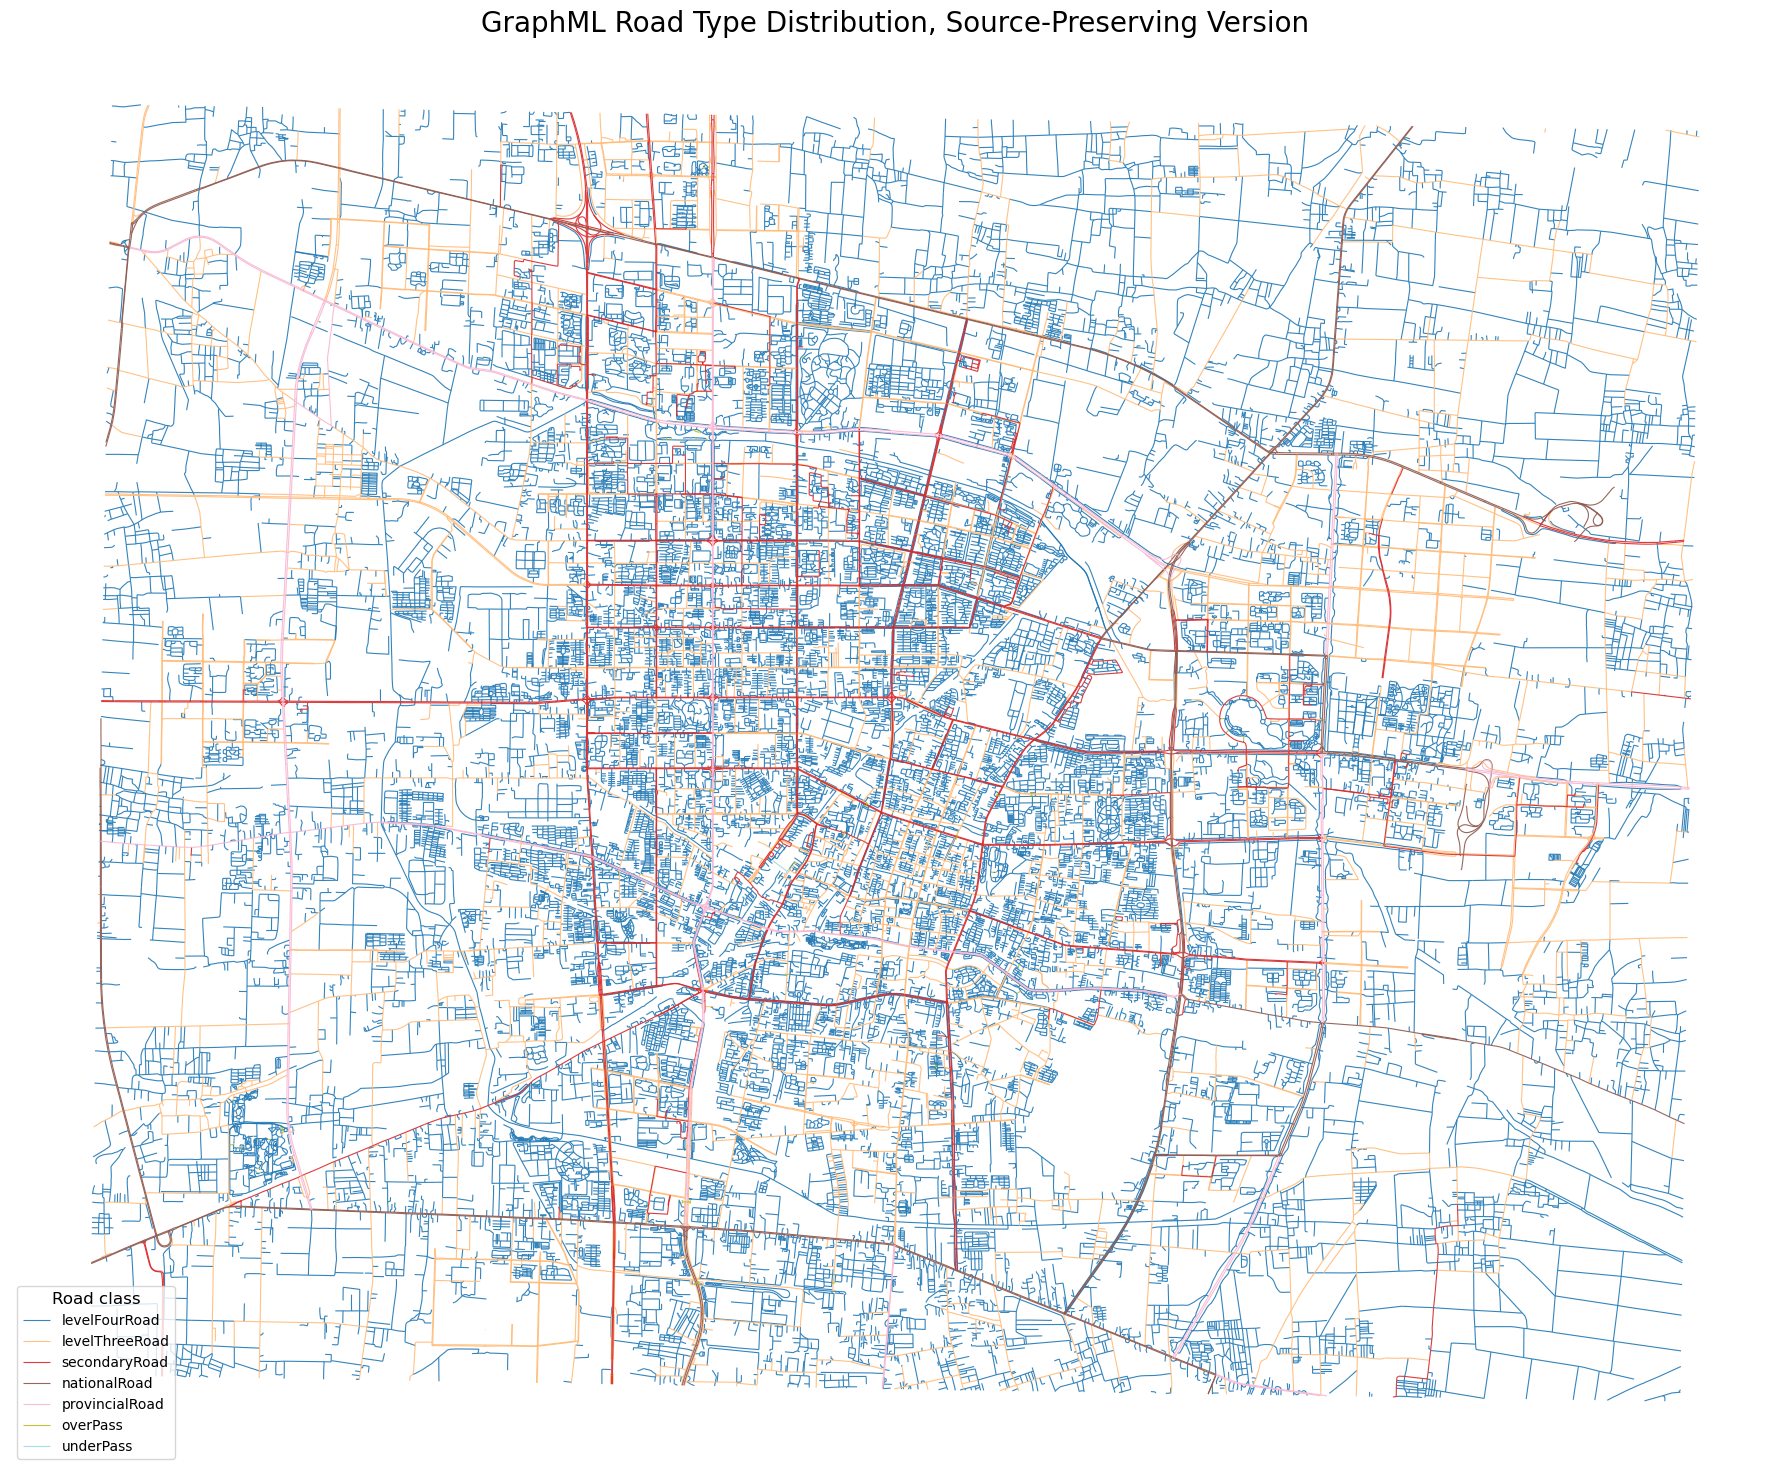

Saved GraphML type map: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/road_repair_outputs/road_type_diagnostics_source_preserving/graphml_road_type_map_source_preserving.png


In [ ]:
# =========================================================
# 3.1 Source-preserving GraphML type validation
#     Validate GraphML road classes against Road_source_preserving_segments.gpkg
#     Python 3.8 compatible
# =========================================================

import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import osmnx as ox


# =========================================================
# Config
# =========================================================

GRAPH_PATH = Path(GRAPH_FILE)
SOURCE_SEGMENTS_GPKG = Path(ROAD_REPAIR_OUTPUT_DIR) / "Road_source_preserving_segments.gpkg"
SOURCE_SEGMENTS_LAYER = "roads"

OUT_DIR = Path(ROAD_REPAIR_OUTPUT_DIR) / "road_type_diagnostics_source_preserving"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_INTERNAL_CHECK_CSV = OUT_DIR / "graphml_vs_source_preserving_segments_type_check.csv"
OUT_INTERNAL_SUMMARY_CSV = OUT_DIR / "graphml_vs_source_preserving_segments_type_summary.csv"
OUT_TYPE_MAP = OUT_DIR / "graphml_road_type_map_source_preserving.png"

UNKNOWN_LABEL = "Unknown"

GRAPH_CLASS_CANDIDATES = [
    "road_class_recovered",
    "_source_road_class",
    "highway",
    "EN_Class",
    "CN_Class",
]

SOURCE_CLASS_CANDIDATES = [
    "_source_road_class",
    "EN_Class",
    "CN_Class",
    "highway",
]

DPI = 300


# =========================================================
# Helpers
# =========================================================

def graph_to_gdfs_compat(G, nodes=False, edges=True):
    try:
        return ox.graph_to_gdfs(G, nodes=nodes, edges=edges)
    except AttributeError:
        return ox.convert.graph_to_gdfs(G, nodes=nodes, edges=edges)


def clean_text(v):
    if pd.isna(v):
        return ""
    s = str(v).strip()
    if s in {"", "nan", "None", "<NA>", "[]"}:
        return ""
    return s


def normalize_road_class(v):
    s = clean_text(v)

    if s == "":
        return UNKNOWN_LABEL

    s = s.replace("[", "").replace("]", "")
    s = s.replace("'", "").replace('"', "")
    s = s.strip()

    if ";" in s:
        s = s.split(";")[0].strip()
    elif "," in s:
        s = s.split(",")[0].strip()

    if s == "":
        return UNKNOWN_LABEL

    return s


def parse_bool_like(x):
    s = clean_text(x).lower()
    return s in {"true", "1", "yes", "y"}


def file_mtime_text(path):
    path = Path(path)
    if not path.exists():
        return "missing"
    ts = os.path.getmtime(str(path))
    return datetime.fromtimestamp(ts).strftime("%Y-%m-%d %H:%M:%S")


def first_existing_col(df, candidates, label):
    print("\nColumn check:", label)

    best_col = None
    best_share = -1.0

    for c in candidates:
        if c in df.columns:
            vals = df[c].apply(clean_text)
            nonempty_share = float((vals != "").mean())
            unique_n = int(vals[vals != ""].nunique())

            print(
                "  %s: non-empty share %.3f, unique %d"
                % (c, nonempty_share, unique_n)
            )

            if nonempty_share > best_share:
                best_col = c
                best_share = nonempty_share

    if best_col is None:
        print("  No class column found for %s." % label)
        return None

    print("  Selected class column for %s: %s" % (label, best_col))
    return best_col


def load_graph_edges_oneway(graph_path):
    if not graph_path.exists():
        raise FileNotFoundError("GraphML not found: %s" % graph_path)

    print("Loading GraphML:", graph_path)
    print("GraphML modified time:", file_mtime_text(graph_path))

    G = ox.load_graphml(str(graph_path))
    edges = graph_to_gdfs_compat(G, nodes=False, edges=True).reset_index()

    print("Raw directed GraphML edges:", len(edges))
    print("GraphML edge columns:")
    print(list(edges.columns))

    if "reversed" in edges.columns:
        reversed_mask = edges["reversed"].apply(parse_bool_like)
        edges_oneway = edges[~reversed_mask].copy()
        print("Non-reversed GraphML edges:", len(edges_oneway))
    else:
        print("No reversed column found. Using all GraphML edges.")
        edges_oneway = edges.copy()

    if "segment_id" not in edges_oneway.columns:
        raise ValueError(
            "GraphML has no segment_id. This is likely not the source-preserving GraphML."
        )

    edges_oneway["segment_id"] = pd.to_numeric(
        edges_oneway["segment_id"],
        errors="coerce",
    )
    edges_oneway = edges_oneway[edges_oneway["segment_id"].notna()].copy()
    edges_oneway["segment_id"] = edges_oneway["segment_id"].astype(int)

    return edges_oneway


def load_source_segments(path, layer):
    if not path.exists():
        raise FileNotFoundError(
            "Source-preserving segment GPKG not found: %s" % path
        )

    print("\nLoading source-preserving segments:", path)
    print("Source segment modified time:", file_mtime_text(path))

    seg = gpd.read_file(path, layer=layer)

    print("Source-preserving segment rows:", len(seg))
    print("Source segment columns:")
    print(list(seg.columns))

    if "segment_id" not in seg.columns:
        raise ValueError("Source segment file has no segment_id.")

    seg["segment_id"] = pd.to_numeric(seg["segment_id"], errors="coerce")
    seg = seg[seg["segment_id"].notna()].copy()
    seg["segment_id"] = seg["segment_id"].astype(int)

    return seg


# =========================================================
# Load files
# =========================================================

graph_edges = load_graph_edges_oneway(GRAPH_PATH)
source_segments = load_source_segments(SOURCE_SEGMENTS_GPKG, SOURCE_SEGMENTS_LAYER)

graph_class_col = first_existing_col(
    graph_edges,
    GRAPH_CLASS_CANDIDATES,
    "GraphML",
)
source_class_col = first_existing_col(
    source_segments,
    SOURCE_CLASS_CANDIDATES,
    "source-preserving segments",
)

if graph_class_col is None:
    raise ValueError("No usable class column in GraphML.")

if source_class_col is None:
    raise ValueError("No usable class column in source-preserving segments.")

graph_edges["graph_class_clean"] = graph_edges[graph_class_col].apply(
    normalize_road_class
)
source_segments["source_class_clean"] = source_segments[source_class_col].apply(
    normalize_road_class
)

if "length" in graph_edges.columns:
    graph_edges["graph_length_m"] = pd.to_numeric(
        graph_edges["length"],
        errors="coerce",
    )
else:
    graph_edges["graph_length_m"] = np.nan

graph_edges["graph_length_m"] = graph_edges["graph_length_m"].fillna(
    graph_edges.geometry.length
)

source_attrs = source_segments[["segment_id", "source_class_clean"]].copy()

dup_source = int(source_attrs["segment_id"].duplicated().sum())
if dup_source > 0:
    print("Warning: duplicated segment_id in source segments:", dup_source)
    source_attrs = source_attrs.drop_duplicates("segment_id", keep="first").copy()

check = graph_edges.merge(
    source_attrs,
    on="segment_id",
    how="left",
)

check["internal_match_status"] = np.where(
    check["source_class_clean"].isna(),
    "segment_id_missing_in_source_gpkg",
    np.where(
        check["graph_class_clean"] == check["source_class_clean"],
        "type_match_internal",
        "type_mismatch_internal",
    ),
)

check_table = check[[
    "u",
    "v",
    "key",
    "segment_id",
    "graph_class_clean",
    "source_class_clean",
    "internal_match_status",
    "graph_length_m",
]].copy()

summary = (
    check_table
    .groupby("internal_match_status", dropna=False)
    .agg(
        edge_count=("segment_id", "size"),
        total_length_m=("graph_length_m", "sum"),
    )
    .reset_index()
    .sort_values("total_length_m", ascending=False)
)

summary["edge_share"] = summary["edge_count"] / summary["edge_count"].sum()
summary["length_share"] = summary["total_length_m"] / summary["total_length_m"].sum()

check_table.to_csv(OUT_INTERNAL_CHECK_CSV, index=False)
summary.to_csv(OUT_INTERNAL_SUMMARY_CSV, index=False)

print("\nInternal GraphML vs source-preserving GPKG type summary:")
try:
    display(summary)
except Exception:
    print(summary.to_string(index=False))

print("\nTop internal mismatches:")
mismatch = check_table[
    check_table["internal_match_status"] != "type_match_internal"
].sort_values("graph_length_m", ascending=False)

try:
    display(mismatch.head(50))
except Exception:
    print(mismatch.head(50).to_string(index=False))

print("Saved internal check:", OUT_INTERNAL_CHECK_CSV)
print("Saved internal summary:", OUT_INTERNAL_SUMMARY_CSV)


# =========================================================
# Hard sanity checks
# =========================================================

source_segment_count = len(source_segments)
graph_nonreversed_count = len(graph_edges)
unique_graph_segment_count = graph_edges["segment_id"].nunique()
unique_source_segment_count = source_segments["segment_id"].nunique()

print("\nSanity counts")
print("Source segment rows:", source_segment_count)
print("Graph non-reversed edges:", graph_nonreversed_count)
print("Unique graph segment_id:", unique_graph_segment_count)
print("Unique source segment_id:", unique_source_segment_count)

missing_segment_share = float(
    (check_table["internal_match_status"] == "segment_id_missing_in_source_gpkg").mean()
)

if check_table["graph_length_m"].sum() > 0:
    mismatch_length_share = float(
        check_table.loc[
            check_table["internal_match_status"] == "type_mismatch_internal",
            "graph_length_m",
        ].sum()
        / check_table["graph_length_m"].sum()
    )
else:
    mismatch_length_share = np.nan

print("\nInternal mismatch length share: %.6f" % mismatch_length_share)
print("Missing segment_id share: %.6f" % missing_segment_share)

if missing_segment_share > 0:
    raise ValueError(
        "Some GraphML segment_id values are missing from Road_source_preserving_segments.gpkg."
    )

if mismatch_length_share > 0.001:
    raise ValueError(
        "GraphML road classes do not match Road_source_preserving_segments.gpkg by segment_id."
    )

print("\nInternal type assignment looks consistent.")


# =========================================================
# Road type spatial distribution from GraphML
# =========================================================

plot_gdf = check.copy()

type_order = (
    plot_gdf
    .groupby("graph_class_clean")["graph_length_m"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

cmap = plt.cm.get_cmap("tab20", max(len(type_order), 1))
type_color = {}
for i, cls in enumerate(type_order):
    type_color[cls] = cmap(i)

fig, ax = plt.subplots(figsize=(18, 18))

for cls in type_order:
    sub = plot_gdf[plot_gdf["graph_class_clean"] == cls]
    if len(sub) == 0:
        continue

    sub.plot(
        ax=ax,
        color=type_color[cls],
        linewidth=0.8,
        alpha=0.9,
        label=cls,
    )

ax.set_title("GraphML Road Type Distribution, Source-Preserving Version", fontsize=20)
ax.axis("off")

ax.legend(
    title="Road class",
    loc="lower left",
    frameon=True,
    fontsize=10,
    title_fontsize=12,
)

plt.tight_layout()
plt.savefig(OUT_TYPE_MAP, dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved GraphML type map:", OUT_TYPE_MAP)

## 3. Virtual-edge distance calculation

The route-level distance is calculated with the same midpoint path idea. The added fields `segment_network_dists`, `segment_modes`, and `path_backbone_segments` let us expand each route into segment rows later.

In [ ]:
# =========================================================
# 4. Virtual-edge route distance calculation
# =========================================================
def try_relabel_nodes_to_int(G):
    mapping = {}
    for n in G.nodes():
        try:
            mapping[n] = int(n)
        except Exception:
            return G, False
    if len(set(mapping.values())) != len(mapping):
        return G, False
    import networkx as nx
    return nx.relabel_nodes(G, mapping, copy=True), True


def edge_id_to_str(edge_id):
    if edge_id is None:
        return None
    u, v, k = edge_id
    return f"{u}|{v}|{k}"


def normalize_nearest_edges_output(nearest_result, n_expected):
    if n_expected == 0:
        return []
    if n_expected == 1 and isinstance(nearest_result, tuple) and len(nearest_result) == 3:
        a0 = nearest_result[0]
        if not hasattr(a0, "__len__") or isinstance(a0, (str, bytes)):
            return [nearest_result]
    try:
        nearest_list = list(nearest_result)
        if len(nearest_list) == n_expected and all(isinstance(x, tuple) and len(x) == 3 for x in nearest_list):
            return nearest_list
    except Exception:
        pass
    if isinstance(nearest_result, tuple) and len(nearest_result) == 3:
        u_arr, v_arr, k_arr = nearest_result
        if len(u_arr) == n_expected:
            return list(zip(u_arr, v_arr, k_arr))
    raise ValueError("Cannot parse OSMnx nearest_edges output. Check the installed OSMnx version.")


def snap_points_batch(G_snap, edge_lookup, xs, ys):
    import osmnx as ox
    from shapely.geometry import Point

    nearest = ox.distance.nearest_edges(G_snap, X=xs, Y=ys)
    edge_ids = normalize_nearest_edges_output(nearest, len(xs))

    out = []
    for edge_id, x, y in zip(edge_ids, xs, ys):
        info = edge_lookup.get(edge_id)
        if info is None:
            out.append(None)
            continue

        geom = info["geometry"]
        edge_len = info["length"]
        geom_len = geom.length

        pt = Point(float(x), float(y))
        proj = float(geom.project(pt))
        snap_pt = geom.interpolate(proj)
        frac = 0.5 if geom_len <= 0 else min(max(proj / geom_len, 0.0), 1.0)

        s_m = edge_len * frac
        offset_m = float(np.hypot(float(snap_pt.x) - float(x), float(snap_pt.y) - float(y)))
        u, v, k = edge_id
        out.append({
            "edge_id": edge_id,
            "u": u,
            "v": v,
            "key": k,
            "edge_len": float(edge_len),
            "s_m": float(s_m),
            "dist_to_u": float(s_m),
            "dist_to_v": float(edge_len - s_m),
            "snap_x": float(snap_pt.x),
            "snap_y": float(snap_pt.y),
            "offset_m": float(offset_m),
        })
    return out


def detect_midpoint_ids(df: pd.DataFrame):
    mid_lng_cols = [c for c in df.columns if re.match(r"mid_\d+_lng$", str(c))]
    return sorted(int(c.split("_")[1]) for c in mid_lng_cols)


def build_waypoint_list_for_row(rid, start_snaps, end_snaps, mid_snap_map, max_mid):
    s0 = start_snaps[rid]
    s1 = end_snaps[rid]
    if s0 is None or s1 is None:
        return None
    waypoints = [s0]
    for i in range(1, max_mid + 1):
        cur = mid_snap_map.get(i)
        if cur is None:
            continue
        snap = cur[rid]
        if snap is not None:
            waypoints.append(snap)
    waypoints.append(s1)
    return waypoints if len(waypoints) >= 2 else None


def choose_best_segment_solution(A, B, node_map, pair_to_dist, pair_to_nodes):
    candidates = []

    if A["edge_id"] == B["edge_id"]:
        candidates.append({
            "mode": "same_edge",
            "total_m": float(abs(float(A["s_m"]) - float(B["s_m"]))),
            "backbone_nodes": tuple(),
        })

    A_endpoints = [("u", A["u"], float(A["dist_to_u"])), ("v", A["v"], float(A["dist_to_v"]))]
    B_endpoints = [("u", B["u"], float(B["dist_to_u"])), ("v", B["v"], float(B["dist_to_v"]))]

    for a_label, a_node, a_cost in A_endpoints:
        for b_label, b_node, b_cost in B_endpoints:
            src_ix = node_map.get(a_node)
            dst_ix = node_map.get(b_node)
            if src_ix is None or dst_ix is None:
                continue
            if src_ix == dst_ix:
                sp_dist = 0.0
                sp_nodes = (a_node,)
            else:
                sp_dist = pair_to_dist.get((src_ix, dst_ix), np.inf)
                sp_nodes = pair_to_nodes.get((src_ix, dst_ix), tuple())
            if np.isfinite(sp_dist):
                candidates.append({
                    "mode": f"{a_label}->{b_label}",
                    "total_m": float(a_cost + sp_dist + b_cost),
                    "backbone_nodes": tuple(sp_nodes),
                })

    if not candidates:
        return {"ok": False, "total_m": np.nan, "backbone_nodes": tuple(), "mode": "no_path"}

    candidates.sort(key=lambda z: (z["total_m"], 0 if z["mode"] == "same_edge" else 1, len(z["backbone_nodes"])))
    best = candidates[0]
    best["ok"] = True
    return best


def calculate_virtual_edge_routes(result: pd.DataFrame, graph_file: Path = GRAPH_FILE, output_csv: Optional[Path] = ROUTE_DISTANCE_CSV) -> pd.DataFrame:
    import igraph as ig
    import osmnx as ox
    import pyproj
    from pyproj import CRS

    if not Path(graph_file).exists():
        raise FileNotFoundError(f"Missing graph file: {graph_file}")
    if result.empty:
        raise ValueError("Input route DataFrame is empty.")

    print("[1/6] loading graph")
    G_raw = ox.load_graphml(str(graph_file))
    G_raw, relabeled = try_relabel_nodes_to_int(G_raw)
    print("nodes relabeled to int:", relabeled)

    graph_crs = G_raw.graph.get("crs")
    if graph_crs is None:
        raise ValueError("Graph is missing CRS.")
    if CRS.from_user_input(graph_crs).is_geographic:
        G_raw = ox.project_graph(G_raw)
        graph_crs = G_raw.graph["crs"]

    G_snap = ox.convert.to_undirected(G_raw)
    nx_nodes = list(G_snap.nodes())
    node_map = {node: i for i, node in enumerate(nx_nodes)}
    reverse_map = {i: node for i, node in enumerate(nx_nodes)}

    pair_min_weight = {}
    for u, v, data in G_snap.edges(data=True):
        if u not in node_map or v not in node_map:
            continue
        iu = node_map[u]
        iv = node_map[v]
        if iu == iv:
            continue
        a, b = (iu, iv) if iu < iv else (iv, iu)
        w = float(data.get("length", 1.0))
        prev = pair_min_weight.get((a, b))
        if prev is None or w < prev:
            pair_min_weight[(a, b)] = w

    ig_edges = list(pair_min_weight.keys())
    ig_weights = list(pair_min_weight.values())
    G_ig = ig.Graph(n=len(nx_nodes), edges=ig_edges, directed=False)
    G_ig.es["weight"] = ig_weights
    print(f"routing graph: nodes={len(nx_nodes):,}, edges={len(ig_edges):,}")

    edges_gdf = ox.graph_to_gdfs(G_snap, nodes=False, fill_edge_geometry=True).reset_index()
    edge_lookup = {}
    for row in edges_gdf.itertuples(index=False):
        edge_id = (row.u, row.v, row.key)
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        edge_len = float(row.length) if hasattr(row, "length") and pd.notna(row.length) else float(geom.length)
        edge_lookup[edge_id] = {"geometry": geom, "length": edge_len}
    print(f"snappable edges: {len(edge_lookup):,}")

    print("[2/6] projecting and snapping points")
    transformer = pyproj.Transformer.from_crs("EPSG:4326", graph_crs, always_xy=True)
    n = len(result)

    start_snaps = [None] * n
    mask_start = result["start_lng"].notna() & result["start_lat"].notna()
    sx = sy = np.array([])
    if mask_start.any():
        sx, sy = transformer.transform(result.loc[mask_start, "start_lng"].values, result.loc[mask_start, "start_lat"].values)
        for rid, snap in zip(np.where(mask_start.values)[0], snap_points_batch(G_snap, edge_lookup, sx, sy)):
            start_snaps[rid] = snap

    end_snaps = [None] * n
    mask_end = result["end_lng"].notna() & result["end_lat"].notna()
    ex = ey = np.array([])
    if mask_end.any():
        ex, ey = transformer.transform(result.loc[mask_end, "end_lng"].values, result.loc[mask_end, "end_lat"].values)
        for rid, snap in zip(np.where(mask_end.values)[0], snap_points_batch(G_snap, edge_lookup, ex, ey)):
            end_snaps[rid] = snap

    mid_ids = detect_midpoint_ids(result)
    max_mid = max(mid_ids) if mid_ids else 0
    print("max midpoint columns:", max_mid)

    mid_snap_map = {}
    for i in range(1, max_mid + 1):
        col_lng = f"mid_{i}_lng"
        col_lat = f"mid_{i}_lat"
        snaps_i = [None] * n
        if col_lng in result.columns and col_lat in result.columns:
            mask_mid = result[col_lng].notna() & result[col_lat].notna()
            if mask_mid.any():
                mx, my = transformer.transform(result.loc[mask_mid, col_lng].values, result.loc[mask_mid, col_lat].values)
                for rid, snap in zip(np.where(mask_mid.values)[0], snap_points_batch(G_snap, edge_lookup, mx, my)):
                    snaps_i[rid] = snap
        mid_snap_map[i] = snaps_i

    print("[3/6] preparing shortest-path endpoint pairs")
    row_waypoints = [None] * n
    src_to_dsts = defaultdict(set)

    for rid in tqdm(range(n), desc="prepare rows"):
        waypoints = build_waypoint_list_for_row(rid, start_snaps, end_snaps, mid_snap_map, max_mid)
        row_waypoints[rid] = waypoints
        if waypoints is None:
            continue
        valid = True
        for A, B in zip(waypoints[:-1], waypoints[1:]):
            if A is None or B is None:
                valid = False
                break
            for src_node in (A["u"], A["v"]):
                for dst_node in (B["u"], B["v"]):
                    src_ix = node_map.get(src_node)
                    dst_ix = node_map.get(dst_node)
                    if src_ix is not None and dst_ix is not None and src_ix != dst_ix:
                        src_to_dsts[src_ix].add(dst_ix)
        if not valid:
            row_waypoints[rid] = None

    print(f"sources needing shortest paths: {len(src_to_dsts):,}")
    pair_to_dist = {}
    pair_to_nodes = {}
    for src_ix, dsts in tqdm(src_to_dsts.items(), total=len(src_to_dsts), desc="shortest paths"):
        dst_list = sorted(dsts)
        if not dst_list:
            continue
        try:
            dmat = G_ig.distances(source=[src_ix], target=dst_list, weights="weight")[0]
            vpaths = G_ig.get_shortest_paths(src_ix, to=dst_list, weights="weight", output="vpath")
        except Exception:
            dmat = [np.inf] * len(dst_list)
            vpaths = [[] for _ in dst_list]
        for dst_ix, dist_val, path_ix in zip(dst_list, dmat, vpaths):
            if np.isfinite(dist_val) and path_ix:
                pair_to_dist[(src_ix, dst_ix)] = float(dist_val)
                pair_to_nodes[(src_ix, dst_ix)] = tuple(reverse_map[ix] for ix in path_ix)
            else:
                pair_to_dist[(src_ix, dst_ix)] = np.inf
                pair_to_nodes[(src_ix, dst_ix)] = tuple()

    print("[4/6] calculating route distances")
    real_start_x = np.full(n, np.nan, dtype=float)
    real_start_y = np.full(n, np.nan, dtype=float)
    real_end_x = np.full(n, np.nan, dtype=float)
    real_end_y = np.full(n, np.nan, dtype=float)
    if mask_start.any():
        real_start_x[mask_start.values] = sx
        real_start_y[mask_start.values] = sy
    if mask_end.any():
        real_end_x[mask_end.values] = ex
        real_end_y[mask_end.values] = ey
    straight_dists = np.hypot(real_end_x - real_start_x, real_end_y - real_start_y)

    calc_method_list = []
    fail_reason_list = []
    dist_network_only_list = []
    dist_offset_start_list = []
    dist_offset_end_list = []
    final_distance_list = []
    missing_edges_list = []
    dist_mode_list = []
    path_backbone_segments_list = []
    segment_modes_list = []
    segment_network_dists_list = []

    start_snap_edge_list = []
    start_snap_x_list = []
    start_snap_y_list = []
    start_snap_offset_list = []
    end_snap_edge_list = []
    end_snap_x_list = []
    end_snap_y_list = []
    end_snap_offset_list = []

    mid_snap_edge_cols = {i: [] for i in range(1, max_mid + 1)}
    mid_snap_x_cols = {i: [] for i in range(1, max_mid + 1)}
    mid_snap_y_cols = {i: [] for i in range(1, max_mid + 1)}
    mid_snap_offset_cols = {i: [] for i in range(1, max_mid + 1)}

    for rid in tqdm(range(n), desc="route distances"):
        straight_dist = float(straight_dists[rid]) if np.isfinite(straight_dists[rid]) else np.nan
        waypoints = row_waypoints[rid]
        s0 = start_snaps[rid]
        s1 = end_snaps[rid]

        if s0 is None:
            start_snap_edge_list.append(None)
            start_snap_x_list.append(np.nan)
            start_snap_y_list.append(np.nan)
            start_snap_offset_list.append(np.nan)
        else:
            start_snap_edge_list.append(edge_id_to_str(s0["edge_id"]))
            start_snap_x_list.append(s0["snap_x"])
            start_snap_y_list.append(s0["snap_y"])
            start_snap_offset_list.append(s0["offset_m"])

        if s1 is None:
            end_snap_edge_list.append(None)
            end_snap_x_list.append(np.nan)
            end_snap_y_list.append(np.nan)
            end_snap_offset_list.append(np.nan)
        else:
            end_snap_edge_list.append(edge_id_to_str(s1["edge_id"]))
            end_snap_x_list.append(s1["snap_x"])
            end_snap_y_list.append(s1["snap_y"])
            end_snap_offset_list.append(s1["offset_m"])

        for i in range(1, max_mid + 1):
            snap_i = mid_snap_map[i][rid]
            if snap_i is None:
                mid_snap_edge_cols[i].append(None)
                mid_snap_x_cols[i].append(np.nan)
                mid_snap_y_cols[i].append(np.nan)
                mid_snap_offset_cols[i].append(np.nan)
            else:
                mid_snap_edge_cols[i].append(edge_id_to_str(snap_i["edge_id"]))
                mid_snap_x_cols[i].append(snap_i["snap_x"])
                mid_snap_y_cols[i].append(snap_i["snap_y"])
                mid_snap_offset_cols[i].append(snap_i["offset_m"])

        if waypoints is None or len(waypoints) < 2:
            calc_method_list.append("error_straight")
            fail_reason_list.append("snap_failed")
            dist_network_only_list.append(np.nan)
            dist_offset_start_list.append(np.nan)
            dist_offset_end_list.append(np.nan)
            final_distance_list.append(straight_dist)
            missing_edges_list.append(np.nan)
            dist_mode_list.append("straight_fallback")
            path_backbone_segments_list.append("")
            segment_modes_list.append("")
            segment_network_dists_list.append("")
            continue

        seg_dists = []
        seg_backbones = []
        seg_modes = []
        ok = True
        fail_reason = ""

        for A, B in zip(waypoints[:-1], waypoints[1:]):
            best = choose_best_segment_solution(A, B, node_map, pair_to_dist, pair_to_nodes)
            if not best["ok"]:
                ok = False
                fail_reason = "no_path"
                break
            seg_dists.append(float(best["total_m"]))
            seg_backbones.append(",".join(map(str, best["backbone_nodes"])) if best["backbone_nodes"] else "")
            seg_modes.append(best["mode"])

        if not ok:
            calc_method_list.append("error_straight")
            fail_reason_list.append(fail_reason or "no_path")
            dist_network_only_list.append(np.nan)
            dist_offset_start_list.append(np.nan)
            dist_offset_end_list.append(np.nan)
            final_distance_list.append(straight_dist)
            missing_edges_list.append(np.nan)
            dist_mode_list.append("straight_fallback")
            path_backbone_segments_list.append("")
            segment_modes_list.append("")
            segment_network_dists_list.append("")
            continue

        net_dist = float(np.sum(seg_dists))
        d_start = float(s0["offset_m"]) if s0 is not None else np.nan
        d_end = float(s1["offset_m"]) if s1 is not None else np.nan
        total = net_dist + (0.0 if np.isnan(d_start) else d_start) + (0.0 if np.isnan(d_end) else d_end)

        calc_method_list.append("virtual_edge_network")
        fail_reason_list.append("")
        dist_network_only_list.append(net_dist)
        dist_offset_start_list.append(d_start)
        dist_offset_end_list.append(d_end)
        final_distance_list.append(total)
        missing_edges_list.append(0)
        dist_mode_list.append("network_ok")
        path_backbone_segments_list.append(";".join(seg_backbones))
        segment_modes_list.append(";".join(seg_modes))
        segment_network_dists_list.append(";".join(f"{x:.6f}" for x in seg_dists))

    print("[5/6] writing result columns")
    out = result.copy()
    out["parent_route_id"] = np.arange(len(out), dtype=int)
    out["calc_method"] = calc_method_list
    out["fail_reason"] = fail_reason_list
    out["dist_network_only"] = dist_network_only_list
    out["dist_offset_start"] = dist_offset_start_list
    out["dist_offset_end"] = dist_offset_end_list
    out["final_distance_m"] = final_distance_list
    out["missing_edges"] = missing_edges_list
    out["dist_mode"] = dist_mode_list
    out["path_backbone_segments"] = path_backbone_segments_list
    out["segment_modes"] = segment_modes_list
    out["segment_network_dists"] = segment_network_dists_list

    out["start_snap_edge"] = start_snap_edge_list
    out["start_snap_x"] = start_snap_x_list
    out["start_snap_y"] = start_snap_y_list
    out["start_snap_offset_m"] = start_snap_offset_list
    out["end_snap_edge"] = end_snap_edge_list
    out["end_snap_x"] = end_snap_x_list
    out["end_snap_y"] = end_snap_y_list
    out["end_snap_offset_m"] = end_snap_offset_list

    for i in range(1, max_mid + 1):
        out[f"mid_{i}_snap_edge"] = mid_snap_edge_cols[i]
        out[f"mid_{i}_snap_x"] = mid_snap_x_cols[i]
        out[f"mid_{i}_snap_y"] = mid_snap_y_cols[i]
        out[f"mid_{i}_snap_offset_m"] = mid_snap_offset_cols[i]

    print("[6/6] complete")
    if output_csv is not None:
        write_csv_atomic(out, output_csv, index=False)
    print(out["dist_mode"].value_counts(dropna=False).head(10))
    return out


In [ ]:
# =========================================================
# 5. Run or load route-level distance calculation
# =========================================================
ROUTE_DISTANCE_REQUIRED_COLUMNS = [
    "parent_route_id", "calc_method", "dist_network_only", "dist_offset_start", "dist_offset_end",
    "final_distance_m", "dist_mode", "segment_network_dists", "segment_modes", "path_backbone_segments",
    "start_snap_edge", "start_snap_x", "start_snap_y", "start_snap_offset_m",
    "end_snap_edge", "end_snap_x", "end_snap_y", "end_snap_offset_m",
]

if should_reuse_csv(ROUTE_DISTANCE_CSV, force=FORCE_RECALCULATE_ROUTE_DISTANCES, required_columns=ROUTE_DISTANCE_REQUIRED_COLUMNS):
    route_distances = read_existing_csv(ROUTE_DISTANCE_CSV, required_columns=ROUTE_DISTANCE_REQUIRED_COLUMNS)
else:
    route_distances = calculate_virtual_edge_routes(routes, graph_file=GRAPH_FILE, output_csv=ROUTE_DISTANCE_CSV)

print("route-level distance rows:", len(route_distances))
route_distances.head()


[1/6] loading graph
nodes relabeled to int: True
routing graph: nodes=50,419, edges=67,810
snappable edges: 68,847
[2/6] projecting and snapping points
max midpoint columns: 11
[3/6] preparing shortest-path endpoint pairs


prepare rows: 100%|██████████| 1137090/1137090 [00:03<00:00, 321990.37it/s]


sources needing shortest paths: 31,237


shortest paths:   0%|          | 0/31237 [00:00<?, ?it/s]/var/folders/jq/7jf33_vn5bjcn7nj1737c9gh0000gn/T/ipykernel_77872/3044941493.py:277: RuntimeWarning: Couldn't reach some vertices. Location: src/paths/dijkstra.c:555
  vpaths = G_ig.get_shortest_paths(src_ix, to=dst_list, weights="weight", output="vpath")
shortest paths: 100%|██████████| 31237/31237 [02:06<00:00, 247.72it/s]


[4/6] calculating route distances


route distances: 100%|██████████| 1137090/1137090 [00:15<00:00, 75512.01it/s]


[5/6] writing result columns
[6/6] complete
saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/courier_final_distances_midpoint_routes_virtual_edge.csv
dist_mode
network_ok           1136430
straight_fallback        660
Name: count, dtype: int64
route-level distance rows: 1137090


,dt,courier_id,wave_id,start_time,end_time,duration,start_action,end_action,start_order_id,end_order_id,start_type,end_type,start_lng,start_lat,end_lng,end_lat,min_deadline_time,time_pressure_sec,time_pressure_min,mid_1_time,mid_1_lng,mid_1_lat,mid_1_order_id,mid_1_min_deadline_time,mid_1_time_pressure_sec,mid_1_time_pressure_min,mid_2_time,mid_2_lng,mid_2_lat,mid_2_order_id,mid_2_min_deadline_time,mid_2_time_pressure_sec,mid_2_time_pressure_min,mid_3_time,mid_3_lng,mid_3_lat,mid_3_order_id,mid_3_min_deadline_time,mid_3_time_pressure_sec,mid_3_time_pressure_min,mid_4_time,mid_4_lng,mid_4_lat,mid_4_order_id,mid_4_min_deadline_time,mid_4_time_pressure_sec,mid_4_time_pressure_min,mid_5_time,mid_5_lng,mid_5_lat,mid_5_order_id,mid_5_min_deadline_time,mid_5_time_pressure_sec,mid_5_time_pressure_min,mid_6_time,mid_6_lng,mid_6_lat,mid_6_order_id,mid_6_min_deadline_time,mid_6_time_pressure_sec,...,dist_offset_start,dist_offset_end,final_distance_m,missing_edges,dist_mode,path_backbone_segments,segment_modes,segment_network_dists,start_snap_edge,start_snap_x,start_snap_y,start_snap_offset_m,end_snap_edge,end_snap_x,end_snap_y,end_snap_offset_m,mid_1_snap_edge,mid_1_snap_x,mid_1_snap_y,mid_1_snap_offset_m,mid_2_snap_edge,mid_2_snap_x,mid_2_snap_y,mid_2_snap_offset_m,mid_3_snap_edge,mid_3_snap_x,mid_3_snap_y,mid_3_snap_offset_m,mid_4_snap_edge,mid_4_snap_x,mid_4_snap_y,mid_4_snap_offset_m,mid_5_snap_edge,mid_5_snap_x,mid_5_snap_y,mid_5_snap_offset_m,mid_6_snap_edge,mid_6_snap_x,mid_6_snap_y,mid_6_snap_offset_m,mid_7_snap_edge,mid_7_snap_x,mid_7_snap_y,mid_7_snap_offset_m,mid_8_snap_edge,mid_8_snap_x,mid_8_snap_y,mid_8_snap_offset_m,mid_9_snap_edge,mid_9_snap_x,mid_9_snap_y,mid_9_snap_offset_m,mid_10_snap_edge,mid_10_snap_x,mid_10_snap_y,mid_10_snap_offset_m,mid_11_snap_edge,mid_11_snap_x,mid_11_snap_y,mid_11_snap_offset_m
0,20221017,0,1,1666015199,1666015698,499,GRAB,FETCH,171478,171478,Spot_Where_Grabbed,Merchant,115.481704,38.861319,115.481495,38.862495,1666017853,2654,44.233333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.385492,12.313779,205.072229,0.0,network_ok,"7341,7342,7379",v->u,180.372957,7340|7341|0,368280.216364,4.302478e+06,12.385492,7379|7385|0,368264.581411,4.302611e+06,12.313779,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN
1,20221017,0,1,1666015698,1666016427,729,FETCH,DELIVER,171478,171478,Merchant,Customer,115.481495,38.862495,115.512333,38.843112,1666017853,2155,35.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.313779,25.352258,4545.319241,0.0,network_ok,"7379,7342,7362,7361,7378,7377,7468,7284,7263,7...",u->v,4507.653203,7379|7385|0,368264.581411,4.302611e+06,12.313779,5210|5213|0,370869.543833,4.300427e+06,25.352258,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN
2,20221017,0,2,1666019273,1666019846,573,GRAB,FETCH,116902,116902,Spot_Where_Grabbed,Merchant,115.494035,38.854560,115.496911,38.862131,1666021662,2389,39.816667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.258071,3.521144,1176.630492,0.0,network_ok,"6734,6736,6749,6752,6754,6755,6769,6827,6851,6...",v->u,1162.851277,6718|6734|0,369324.831165,4.301704e+06,10.258071,15547|15551|0,369586.085036,4.302552e+06,3.521144,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN
3,2022101

## 4. Expand midpoint routes into segment-level rows

Each route is cut into:

`start -> mid_1`, `mid_1 -> mid_2`, ..., `mid_k -> end`.

The path and network distance still come from the midpoint route calculation. Speed is then calculated per expanded segment.

In [ ]:
# =========================================================
# 6. Expand route-level output into segment-level output
# =========================================================
def parse_float_list(s):
    if s is None or pd.isna(s):
        return []
    s = str(s).strip()
    if not s or s.lower() in {"nan", "<na>"}:
        return []
    out = []
    for part in s.split(";"):
        part = part.strip()
        if not part:
            out.append(np.nan)
            continue
        try:
            out.append(float(part))
        except Exception:
            out.append(np.nan)
    return out


def parse_str_list(s):
    if s is None or pd.isna(s):
        return []
    s = str(s).strip()
    if not s or s.lower() in {"nan", "<na>"}:
        return []
    return s.split(";")


def haversine_pair_m(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(float, [lon1, lat1, lon2, lat2])
    lon1 = math.radians(lon1)
    lat1 = math.radians(lat1)
    lon2 = math.radians(lon2)
    lat2 = math.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2.0) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2.0) ** 2
    return 6371000.0 * 2.0 * math.asin(math.sqrt(a))


def ordered_observation_points(row: pd.Series):
    points = [{
        "source": "start",
        "time": row.get("start_time"),
        "action": row.get("start_action"),
        "order_id": row.get("start_order_id"),
        "type": row.get("start_type"),
        "lng": row.get("start_lng"),
        "lat": row.get("start_lat"),
        "snap_edge": row.get("start_snap_edge"),
        "snap_x": row.get("start_snap_x"),
        "snap_y": row.get("start_snap_y"),
        "snap_offset_m": row.get("start_snap_offset_m", row.get("dist_offset_start")),
        "min_deadline_time": row.get("min_deadline_time"),
        "time_pressure_sec": row.get("time_pressure_sec"),
        "time_pressure_min": row.get("time_pressure_min"),
    }]

    mid_ids = detect_midpoint_ids(pd.DataFrame(columns=row.index))
    if not mid_ids:
        mid_ids = sorted(
            int(str(c).split("_")[1])
            for c in row.index
            if re.match(r"mid_\d+_time$", str(c))
        )

    for i in mid_ids:
        t = row.get(f"mid_{i}_time", np.nan)
        lng = row.get(f"mid_{i}_lng", np.nan)
        lat = row.get(f"mid_{i}_lat", np.nan)
        if pd.isna(t) or pd.isna(lng) or pd.isna(lat):
            continue
        points.append({
            "source": f"mid_{i}",
            "time": t,
            "action": "GRAB",
            "order_id": row.get(f"mid_{i}_order_id"),
            "type": "Spot_Where_Grabbed",
            "lng": lng,
            "lat": lat,
            "snap_edge": row.get(f"mid_{i}_snap_edge"),
            "snap_x": row.get(f"mid_{i}_snap_x"),
            "snap_y": row.get(f"mid_{i}_snap_y"),
            "snap_offset_m": row.get(f"mid_{i}_snap_offset_m"),
            "min_deadline_time": row.get(f"mid_{i}_min_deadline_time"),
            "time_pressure_sec": row.get(f"mid_{i}_time_pressure_sec"),
            "time_pressure_min": row.get(f"mid_{i}_time_pressure_min"),
        })

    points.append({
        "source": "end",
        "time": row.get("end_time"),
        "action": row.get("end_action"),
        "order_id": row.get("end_order_id"),
        "type": row.get("end_type"),
        "lng": row.get("end_lng"),
        "lat": row.get("end_lat"),
        "snap_edge": row.get("end_snap_edge"),
        "snap_x": row.get("end_snap_x"),
        "snap_y": row.get("end_snap_y"),
        "snap_offset_m": row.get("end_snap_offset_m", row.get("dist_offset_end")),
        "min_deadline_time": np.nan,
        "time_pressure_sec": np.nan,
        "time_pressure_min": np.nan,
    })

    return points


def expand_routes_to_segments(route_df: pd.DataFrame, output_csv: Optional[Path] = SEGMENT_DISTANCE_CSV) -> pd.DataFrame:
    segment_rows = []

    for rid, row in tqdm(route_df.iterrows(), total=len(route_df), desc="expand route rows"):
        parent_route_id = int(row.get("parent_route_id", rid))
        points = ordered_observation_points(row)
        segment_network_dists = parse_float_list(row.get("segment_network_dists", ""))
        segment_modes = parse_str_list(row.get("segment_modes", ""))
        path_backbone_segments = parse_str_list(row.get("path_backbone_segments", ""))

        parent_network_ok = row.get("dist_mode") == "network_ok" and len(segment_network_dists) == len(points) - 1

        for seg_idx, (A, B) in enumerate(zip(points[:-1], points[1:])):
            duration = pd.to_numeric(B["time"], errors="coerce") - pd.to_numeric(A["time"], errors="coerce")
            straight_distance = haversine_pair_m(A["lng"], A["lat"], B["lng"], B["lat"])

            if parent_network_ok:
                dist_network_only = float(segment_network_dists[seg_idx])
                offset_start = pd.to_numeric(A.get("snap_offset_m"), errors="coerce")
                offset_end = pd.to_numeric(B.get("snap_offset_m"), errors="coerce")
                offset_start = 0.0 if pd.isna(offset_start) else float(offset_start)
                offset_end = 0.0 if pd.isna(offset_end) else float(offset_end)
                final_distance = dist_network_only + offset_start + offset_end
                calc_method = "virtual_edge_network"
                dist_mode = "network_ok"
                fail_reason = ""
                missing_edges = 0
            else:
                dist_network_only = np.nan
                offset_start = np.nan
                offset_end = np.nan
                final_distance = straight_distance
                calc_method = "error_straight"
                dist_mode = "straight_fallback"
                fail_reason = row.get("fail_reason", "parent_route_failed") or "parent_route_failed"
                missing_edges = np.nan

            speed_kmh = final_distance / duration * 3.6 if pd.notna(duration) and duration > 0 else np.nan

            segment_rows.append({
                "parent_route_id": parent_route_id,
                "segment_index": seg_idx,
                "segment_count": len(points) - 1,
                "dt": row.get("dt"),
                "courier_id": row.get("courier_id"),
                "wave_id": row.get("wave_id"),
                "start_time": int(A["time"]) if pd.notna(A["time"]) else np.nan,
                "end_time": int(B["time"]) if pd.notna(B["time"]) else np.nan,
                "duration": duration,
                "start_action": A["action"],
                "end_action": B["action"],
                "start_order_id": A["order_id"],
                "end_order_id": B["order_id"],
                "start_type": A["type"],
                "end_type": B["type"],
                "start_lng": A["lng"],
                "start_lat": A["lat"],
                "end_lng": B["lng"],
                "end_lat": B["lat"],
                "min_deadline_time": A["min_deadline_time"],
                "time_pressure_sec": A["time_pressure_sec"],
                "time_pressure_min": A["time_pressure_min"],
                "calc_method": calc_method,
                "fail_reason": fail_reason,
                "dist_network_only": dist_network_only,
                "dist_offset_start": offset_start,
                "dist_offset_end": offset_end,
                "final_distance_m": final_distance,
                "straight_distance_m": straight_distance,
                "speed_kmh": speed_kmh,
                "missing_edges": missing_edges,
                "dist_mode": dist_mode,
                "segment_mode": segment_modes[seg_idx] if seg_idx < len(segment_modes) else "",
                "path_backbone_segment": path_backbone_segments[seg_idx] if seg_idx < len(path_backbone_segments) else "",
                "start_snap_edge": A["snap_edge"],
                "start_snap_x": A["snap_x"],
                "start_snap_y": A["snap_y"],
                "end_snap_edge": B["snap_edge"],
                "end_snap_x": B["snap_x"],
                "end_snap_y": B["snap_y"],
                "parent_start_time": row.get("start_time"),
                "parent_end_time": row.get("end_time"),
                "parent_start_action": row.get("start_action"),
                "parent_end_action": row.get("end_action"),
                "parent_duration": row.get("duration"),
                "parent_dist_network_only": row.get("dist_network_only"),
                "parent_final_distance_m": row.get("final_distance_m"),
                "parent_calc_method": row.get("calc_method"),
                "parent_dist_mode": row.get("dist_mode"),
            })

    out = pd.DataFrame(segment_rows)
    if len(out) > 0:
        out["action_pair"] = out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)
        out["offset_sum"] = pd.to_numeric(out["dist_offset_start"], errors="coerce").fillna(0) + pd.to_numeric(out["dist_offset_end"], errors="coerce").fillna(0)
        out["offset_ratio"] = out["offset_sum"] / (pd.to_numeric(out["dist_network_only"], errors="coerce") + RATIO_EPS)
        out["final_to_straight_ratio"] = pd.to_numeric(out["final_distance_m"], errors="coerce") / (pd.to_numeric(out["straight_distance_m"], errors="coerce") + RATIO_EPS)
        out["network_to_straight_ratio"] = pd.to_numeric(out["dist_network_only"], errors="coerce") / (pd.to_numeric(out["straight_distance_m"], errors="coerce") + RATIO_EPS)

    if output_csv is not None:
        write_csv_atomic(out, output_csv, index=False)
    print("segment rows:", len(out))
    if len(out):
        print(out["action_pair"].value_counts(dropna=False).head(20).to_string())
    return out


SEGMENT_DISTANCE_REQUIRED_COLUMNS = [
    "parent_route_id", "segment_index", "duration", "start_action", "end_action",
    "start_lng", "start_lat", "end_lng", "end_lat",
    "dist_network_only", "final_distance_m", "straight_distance_m", "speed_kmh",
    "dist_mode", "action_pair", "final_to_straight_ratio",
]

if should_reuse_csv(SEGMENT_DISTANCE_CSV, force=FORCE_EXPAND_SEGMENTS, required_columns=SEGMENT_DISTANCE_REQUIRED_COLUMNS):
    segments = read_existing_csv(SEGMENT_DISTANCE_CSV, required_columns=SEGMENT_DISTANCE_REQUIRED_COLUMNS)
else:
    segments = expand_routes_to_segments(route_distances, output_csv=SEGMENT_DISTANCE_CSV)

print("segment rows before filtering:", len(segments))
segments.head()


expand route rows: 100%|██████████| 1137090/1137090 [21:55<00:00, 864.10it/s]


saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/courier_final_distances_segments_virtual_edge.csv
segment rows: 1498887
action_pair
GRAB -> FETCH         290446
FETCH -> DELIVER      275727
DELIVER -> DELIVER    202931
FETCH -> FETCH        192264
GRAB -> GRAB          188212
FETCH -> GRAB         100554
GRAB -> DELIVER        89887
DELIVER -> FETCH       85835
DELIVER -> GRAB        73031
segment rows before filtering: 1498887


,parent_route_id,segment_index,segment_count,dt,courier_id,wave_id,start_time,end_time,duration,start_action,end_action,start_order_id,end_order_id,start_type,end_type,start_lng,start_lat,end_lng,end_lat,min_deadline_time,time_pressure_sec,time_pressure_min,calc_method,fail_reason,dist_network_only,dist_offset_start,dist_offset_end,final_distance_m,straight_distance_m,speed_kmh,missing_edges,dist_mode,segment_mode,path_backbone_segment,start_snap_edge,start_snap_x,start_snap_y,end_snap_edge,end_snap_x,end_snap_y,parent_start_time,parent_end_time,parent_start_action,parent_end_action,parent_duration,parent_dist_network_only,parent_final_distance_m,parent_calc_method,parent_dist_mode,action_pair,offset_sum,offset_ratio,final_to_straight_ratio,network_to_straight_ratio
0,0,0,1,20221017,0,1,1666015199,1666015698,499.0,GRAB,FETCH,171478.0,171478.0,Spot_Where_Grabbed,Merchant,115.481704,38.861319,115.481495,38.862495,1.666018e+09,2654.0,44.233333,virtual_edge_network,,180.372957,12.385492,12.313779,205.072228,132.011389,1.479479,0.0,network_ok,v->u,"7341,7342,7379",7340|7341|0,368280.216364,4.302478e+06,7379|7385|0,368264.581411,4.302611e+06,1666015199,1666015698,GRAB,FETCH,499,180.372957,205.072229,virtual_edge_network,network_ok,GRAB -> FETCH,24.699271,0.136934,1.553443,1.366344
1,1,0,1,20221017,0,1,1666015698,1666016427,729.0,FETCH,DELIVER,171478.0,171478.0,Merchant,Customer,115.481495,38.862495,115.512333,38.843112,1.666018e+09,2155.0,35.916667,virtual_edge_network,,4507.653203,12.313779,25.352258,4545.319241,3431.657001,22.446021,0.0,network_ok,u->v,"7379,7342,7362,7361,7378,7377,7468,7284,7263,7...",7379|7385|0,368264.581411,4.302611e+06,5210|5213|0,370869.543833,4.300427e+06,1666015698,1666016427,FETCH,DELIVER,729,4507.653203,4545.319241,virtual_edge_network,network_ok,FETCH -> DELIVER,37.666038,0.008356,1.324526,1.313550
2,2,0,1,20221017,0,2,1666019273,1666019846,573.0,GRAB,FETCH,116902.0,116902.0,Spot_Where_Grabbed,Merchant,115.494035,38.854560,115.496911,38.862131,1.666022e+09,2389.0,39.816667,virtual_edge_network,,1162.851277,10.258071,3.521144,1176.630492,877.916015,7.392443,0.0,network_ok,v->u,"6734,6736,6749,6752,6754,6755,6769,6827,6851,6...",6718|6734|0,369324.831165,4.301704e+06,15547|15551|0,369586.085036,4.302552e+06,1666019273,1666019846,GRAB,FETCH,573,1162.851277,1176.630492,virtual_edge_network,network_ok,GRAB -> FETCH,13.779215,0.011850,1.340254,1.324559
3,3,0,1,20221017,0,2,1666019846,1666020782,936.0,FETCH,DELIVER,116902.0,116902.0,Merchant,Customer,115.496911,38.862131,115.449958,38.858839,1.666022e+09,1816.0,30.266667,virtual_edge_network,,5440.033642,3.521144,3.995232,5447.550018,4081.863923,20.952115,0.0,network_ok,u->u,"15547,15550,15561,15558,15504,15502,7121,7124,...",15547|15551|0,369586.085036,4.302552e+06,25413|25422|0,365509.099270,4.302250e+06,1666019846,1666020782,FETCH,DELIVER,936,5440.033642,5447.550018,virtual_edge_network,network_ok,FETCH -> DELIVER,7.516376,0.001382,1.334574,1.332733
4,4,0,1,20221017,1,1,1665936737,1665937344,607.0,GRAB,FETCH,1.0,1.0,Spot_Where_Grabbed,Merchant,115.447862,38.905505,115.447730,38.905350,1.665938e+09,1127.0,18.783333,virtual_edge_network,,12.548365,9.899258,6.519401,28.967024,20.676411,0.171798,0.0,network_ok,same_edge,,40916|40918|0,365416.025708,4.307426e+06,40916|40918|0,365403.492051,4.307425e+06,1665936737,1665937344,GRAB,FETCH,607,12.548365,28.967024,virtual_edge_network,network_ok,GRAB -> FETCH,16.418659,1.308430,1.400970,0.606893


## 5. Final filtering on segment-level rows

The same threshold settings are applied after midpoint expansion, so duration, distance, speed, offset ratio, and route ratio are evaluated at the segment level.

In [ ]:
# =========================================================
# 7. Segment-level filtering
# =========================================================
def apply_filter_stage(df: pd.DataFrame, name: str, mask: pd.Series, log: List[Dict[str, Any]]) -> pd.DataFrame:
    before = len(df)
    mask = mask.reindex(df.index).fillna(False)
    out = df.loc[mask].copy()
    after = len(out)
    log.append({
        "stage": name,
        "before": before,
        "after": after,
        "dropped": before - after,
        "kept_pct": after / before * 100 if before else np.nan,
    })
    print(f"{name}: kept {after:,}/{before:,} ({after / before * 100 if before else 0:.2f}%)")
    return out


def filter_segment_distances(df: pd.DataFrame, output_csv: Path = FILTERED_CSV, stage_csv: Path = FILTER_STAGE_SUMMARY_CSV):
    out = df.copy()
    log = []

    numeric_cols = [
        "duration", "final_distance_m", "dist_network_only", "dist_offset_start", "dist_offset_end",
        "straight_distance_m", "speed_kmh", "offset_sum", "offset_ratio", "final_to_straight_ratio",
        "network_to_straight_ratio", "start_lng", "start_lat", "end_lng", "end_lat",
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "action_pair" not in out.columns:
        out["action_pair"] = out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)

    if FILTER_STAGE_0_ENABLE:
        mask = (
            out["start_lat"].between(LAT_MIN, LAT_MAX, inclusive="both") &
            out["end_lat"].between(LAT_MIN, LAT_MAX, inclusive="both") &
            out["start_lng"].between(LNG_MIN, LNG_MAX, inclusive="both") &
            out["end_lng"].between(LNG_MIN, LNG_MAX, inclusive="both")
        )
        out = apply_filter_stage(out, "stage_0_bbox", mask, log)

    mask = (
        out["duration"].between(FILTER_DURATION_MIN, FILTER_DURATION_MAX, inclusive="both") &
        (out["final_distance_m"] > FILTER_FINAL_DIST_MIN) &
        out["speed_kmh"].between(FILTER_SPEED_MIN_KMH, FILTER_SPEED_MAX_KMH, inclusive="both")
    )
    out = apply_filter_stage(out, "stage_1_duration_distance_speed", mask, log)

    if FILTER_ENABLE_OFFSET_RATIO:
        if "offset_ratio" not in out.columns:
            out["offset_sum"] = out["dist_offset_start"].fillna(0) + out["dist_offset_end"].fillna(0)
            out["offset_ratio"] = out["offset_sum"] / (out["dist_network_only"] + RATIO_EPS)
        mask = out["offset_ratio"].notna() & (out["offset_ratio"] < FILTER_OFFSET_RATIO_MAX)
        out = apply_filter_stage(out, "stage_2_offset_ratio", mask, log)

    if FILTER_ENABLE_ROUTE_RATIO:
        if FILTER_ROUTE_RATIO_COL not in out.columns:
            out[FILTER_ROUTE_RATIO_COL] = out["final_distance_m"] / (out["straight_distance_m"] + RATIO_EPS)
        mask = out[FILTER_ROUTE_RATIO_COL].notna() & (out[FILTER_ROUTE_RATIO_COL] <= FILTER_ROUTE_RATIO_MAX)
        out = apply_filter_stage(out, "stage_3_route_ratio", mask, log)

    if FILTER_DROP_PAIRS:
        mask = ~out["action_pair"].isin(FILTER_DROP_PAIRS)
        out = apply_filter_stage(out, "stage_4_action_pair", mask, log)

    if FILTER_STAGE_5_ENABLE:
        mask = pd.Series(True, index=out.index)
        out = apply_filter_stage(out, "stage_5_custom_filter", mask, log)

    stage_df = pd.DataFrame(log)
    write_csv_atomic(out, output_csv, index=False)
    write_csv_atomic(stage_df, stage_csv, index=False)

    print("saved filtered csv:", output_csv)
    print("saved filter stage summary:", stage_csv)
    print("final rows:", len(out))
    return out, stage_df


FILTERED_REQUIRED_COLUMNS = [
    "parent_route_id", "segment_index", "duration", "final_distance_m", "speed_kmh",
    "start_action", "end_action", "action_pair", "dist_mode",
]

if should_reuse_csv(FILTERED_CSV, force=FORCE_REFILTER_SEGMENTS, required_columns=FILTERED_REQUIRED_COLUMNS):
    filtered_segments = read_existing_csv(FILTERED_CSV, required_columns=FILTERED_REQUIRED_COLUMNS)
    if FILTER_STAGE_SUMMARY_CSV.exists():
        filter_stage_summary = pd.read_csv(FILTER_STAGE_SUMMARY_CSV)
    else:
        filter_stage_summary = pd.DataFrame()
else:
    filtered_segments, filter_stage_summary = filter_segment_distances(segments)

print("filtered segment rows:", len(filtered_segments))
filter_stage_summary


stage_0_bbox: kept 1,337,800/1,498,887 (89.25%)
stage_1_duration_distance_speed: kept 482,034/1,337,800 (36.03%)
stage_2_offset_ratio: kept 478,046/482,034 (99.17%)
stage_3_route_ratio: kept 465,249/478,046 (97.32%)
stage_4_action_pair: kept 451,887/465,249 (97.13%)
stage_5_custom_filter: kept 451,887/451,887 (100.00%)
saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/courier_final_distances_filtered.csv
saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/filter_stage_summary.csv
saved filtered csv: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/courier_final_distances_filtered.csv
saved filter stage summary: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/filter_stage_summary.csv
final rows: 451887
filtered segment rows: 451887


,stage,before,after,dropped,kept_pct
0,stage_0_bbox,1498887,1337800,161087,89.252892
1,stage_1_duration_distance_speed,1337800,482034,855766,36.031843
2,stage_2_offset_ratio,482034,478046,3988,99.172672
3,stage_3_route_ratio,478046,465249,12797,97.323061
4,stage_4_action_pair,465249,451887,13362,97.127990
5,stage_5_custom_filter,451887,451887,0,100.000000


In [ ]:
# =========================================================
# 8. Quick validation summaries
# =========================================================
print("route-level rows:", len(route_distances))
print("segment-level rows before filtering:", len(segments))
print("segment-level rows after filtering:", len(filtered_segments))

print("\nfiltered dist_mode counts")
print(filtered_segments["dist_mode"].value_counts(dropna=False).to_string())

print("\nfiltered action_pair counts")
print(filtered_segments["action_pair"].value_counts(dropna=False).head(20).to_string())

print("\nkey numeric summary")
summary_cols = ["duration", "final_distance_m", "straight_distance_m", "speed_kmh", "offset_ratio", "final_to_straight_ratio"]
print(filtered_segments[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

# Network distance consistency check at parent-route level.
if "segment_network_dists" in route_distances.columns:
    diffs = []
    for _, row in route_distances[route_distances["dist_mode"] == "network_ok"].iterrows():
        parts = parse_float_list(row.get("segment_network_dists", ""))
        if parts:
            diffs.append(abs(sum(parts) - float(row["dist_network_only"])))
    if diffs:
        print("\nparent route network-distance split max absolute error:", max(diffs))


route-level rows: 1137090
segment-level rows before filtering: 1498887
segment-level rows after filtering: 451887

filtered dist_mode counts
dist_mode
network_ok    451887

filtered action_pair counts
action_pair
FETCH -> DELIVER      186403
DELIVER -> DELIVER     92864
GRAB -> FETCH          72427
DELIVER -> FETCH       27138
FETCH -> FETCH         25707
FETCH -> GRAB          20661
GRAB -> DELIVER        15773
DELIVER -> GRAB        10914

key numeric summary
                            count         mean          std         min          1%          5%          50%          95%          99%           max
duration                 451887.0   567.156105   276.804345  300.000000  303.000000  315.000000   486.000000  1093.000000  1623.000000   3586.000000
final_distance_m         451887.0  1808.542908  1142.031595  301.306643  418.923335  573.733061  1522.455406  3976.060052  5842.233457  15364.222662
straight_distance_m      451887.0  1335.479142   921.066228  126.647959  252.426277  37

In [ ]:
# =========================================================
# 9. Save raw-stage manifest and hard checks
# =========================================================
required_outputs = [
    GRAPH_FILE,
    MOVEMENTS_ROUTES_CSV,
    ROUTE_DISTANCE_CSV,
    SEGMENT_DISTANCE_CSV,
    FILTERED_CSV,
    FILTER_STAGE_SUMMARY_CSV,
]
missing = [str(p) for p in required_outputs if not Path(p).exists()]
if missing:
    raise FileNotFoundError("Raw rebuild did not produce required outputs: %s" % missing)

stage_manifest = {
    "stage": "01_rebuild_graph_and_segments",
    "graph_file": str(GRAPH_FILE),
    "graph_fingerprint": file_fingerprint(GRAPH_FILE),
    "road_shp": str(ROAD_SHP),
    "road_shp_fingerprint": file_fingerprint(ROAD_SHP),
    "movement_routes_csv": str(MOVEMENTS_ROUTES_CSV),
    "route_distance_csv": str(ROUTE_DISTANCE_CSV),
    "segment_distance_csv": str(SEGMENT_DISTANCE_CSV),
    "filtered_segment_csv": str(FILTERED_CSV),
    "filter_stage_summary_csv": str(FILTER_STAGE_SUMMARY_CSV),
    "output_dir": str(OUTPUT_DIR),
    "resume_from_existing": RESUME_FROM_EXISTING,
    "force_recalculate_route_distances": FORCE_RECALCULATE_ROUTE_DISTANCES,
}
RAW_STAGE_MANIFEST_JSON.write_text(json.dumps(stage_manifest, indent=2, ensure_ascii=False), encoding="utf-8")

# Update global pipeline manifest.
manifest = {}
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
manifest.update({
    "graph_file": str(GRAPH_FILE),
    "raw_segment_dir": str(OUTPUT_DIR),
    "filtered_segment_csv": str(FILTERED_CSV),
    "raw_stage_manifest": str(RAW_STAGE_MANIFEST_JSON),
    "graph_fingerprint": file_fingerprint(GRAPH_FILE),
})
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

print("Raw-stage manifest saved:", RAW_STAGE_MANIFEST_JSON)
print("Pipeline manifest updated:", MANIFEST_PATH)
print(json.dumps(stage_manifest, indent=2, ensure_ascii=False))


Raw-stage manifest saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/raw_stage_manifest.json
Pipeline manifest updated: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/pipeline_manifest.json
{
  "stage": "01_rebuild_graph_and_segments",
  "graph_file": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.graphml",
  "graph_fingerprint": {
    "path": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.graphml",
    "size_bytes": 140710474,
    "mtime": 1779087627.9865012,
    "md5": "5c39e58646ac275b40a6b104dd9c933b"
  },
  "road_shp": "/Users/kwk1001/Desktop/Meituan/baoding/保定数据/Road.shp",
  "road_shp_fingerprint": {
    "path": "/Users/kwk1001/Desktop/Meituan/baoding/保定数据/Road.shp",
    "size_bytes": 58551396,
    "mtime": 1777220284.0,
    "md5": "dfe0753c6b6e7bb56da026eb6a9cd4ba"
  },
  "movement_routes_csv": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/courie